# Notebook 3 — Modelamiento y Forecasting del IPM
## Luces Nocturnas Satelitales y Machine Learning para la Predicción del IPM en la Región Caribe Colombiana (2018–2024)

**Autores:** Juan C. Aguirre & Camilo V. Escorcia — Universidad del Norte, Barranquilla  
**Prerequisitos:** `01_Estructura.ipynb` (dataset limpio) · `02_EDA.ipynb` (hallazgos exploratorios)  

---

## Problema y Enfoque

Este notebook implementa el núcleo predictivo del proyecto: estimar y proyectar el IPM departamental en la Región Caribe utilizando tres enfoques metodológicos complementarios. El diseño responde directamente a los hallazgos del EDA:

- La fuerte **inercia temporal** del IPM (ACF positiva en lag-1) justifica incluir rezagos autorregresivos.
- La **heterocedasticidad** detectada en 2020–2022 y el reducido tamaño muestral (T ≤ 8) favorecen modelos lineales regularizados sobre arquitecturas complejas.
- La **heterogeneidad territorial** exige capturar efectos fijos por departamento, lo que se implementa mediante encoding categórico.
- La señal VIIRS actúa como proxy de actividad económica y puede capturar cambios socioeconómicos antes de que se reflejen en los indicadores formales del DANE.

### Enfoques evaluados

| Enfoque | Variables predictoras | Pregunta que responde |
|---------|----------------------|-----------------------|
| **Temporal** | `ipm_lag1`, `trend`, `pandemia` + departamento | ¿Puede la inercia histórica del IPM predecir el siguiente año? |
| **Nightlights** | `viirs_weighted_log`, `trend`, `pandemia` + departamento | ¿La luminosidad satelital VIIRS predice pobreza sin datos históricos del IPM? |
| **Híbrido** | `ipm_lag1` + `viirs_weighted_log` + tendencia + departamento | ¿La señal satelital aporta información incremental sobre la inercia autorregresiva? |

### Estructura del Notebook

| Sección | Contenido |
|---------|----------|
| 1 | Configuración del entorno: imports, constantes y funciones auxiliares |
| 2 | Carga, limpieza y agregación ponderada a panel departamento-año |
| 3 | Feature Engineering: rezagos, tendencia y marcador de pandemia |
| 4 | Integración de datos exógenos VIIRS |
| 5 | Diagnóstico de series temporales: justificación del benchmark de modelos |
| 6 | Definición de splits temporales y banco de modelos |
| 7 | Walk-Forward Validation por enfoque |
| 8 | Entrenamiento final y evaluación en Test 2024 |
| 9 | Análisis de resultados: comparación, scatter y error por departamento |
| 10 | Forecast 2025 con intervalos de predicción (bootstrap residual) |
| 11 | Resumen ejecutivo |


---
## 1. Configuración del Entorno

Se importan todas las dependencias y se definen las constantes globales del proyecto. El diccionario `COLORS` centraliza la paleta cromática utilizada en todas las visualizaciones del notebook, garantizando que cada enfoque predictivo sea siempre representado con el mismo color a lo largo del documento.


In [9]:
import pandas as pd
import numpy as np
import unicodedata
import warnings
import math
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.preprocessing   import StandardScaler, OneHotEncoder
from sklearn.impute          import SimpleImputer
from sklearn.linear_model    import Ridge, ElasticNet
from sklearn.ensemble        import GradientBoostingRegressor
from sklearn.dummy           import DummyRegressor
from sklearn.metrics         import r2_score
from sklearn.base            import clone
from inspect                 import signature
from statsmodels.graphics.tsaplots import plot_acf

# ── Paleta cromática del proyecto ──────────────────────────────────────────
# Cada enfoque predictivo tiene un color fijo para facilitar la lectura
# cruzada entre gráficos a lo largo del notebook.
COLORS = {
    'real':        '#1a252f',   # Negro oscuro — serie observada
    'temporal':    '#2980b9',   # Azul         — enfoque temporal
    'nightlights': '#27ae60',   # Verde         — enfoque Nightlights
    'hybrid':      '#e67e22',   # Naranja       — enfoque híbrido
    'naive':       '#c0392b',   # Rojo          — baseline Naive
    'pandemic':    '#e74c3c',   # Rojo claro    — marcador pandemia
    'ci80':        '#aed6f1',   # Azul claro    — intervalo de confianza 80%
    'ci95':        '#d6eaf8',   # Azul muy claro — intervalo de confianza 95%
}

# ── Configuración global de gráficos ───────────────────────────────────────
sns.set_theme(style='whitegrid', context='paper', palette='muted')
plt.rcParams.update({
    'figure.dpi':      130,
    'axes.titlepad':   10,
    'axes.titlesize':  12,
    'axes.labelsize':  10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 9,
    'font.family':     'DejaVu Sans',
})

PANDEMIC_YEAR = 2020

print('Entorno configurado correctamente.')


Entorno configurado correctamente.


### 1.1 Funciones Utilitarias

Se definen las funciones auxiliares de preprocesamiento, métricas de evaluación, entrenamiento genérico y visualización. Centralizar estas definiciones evita la duplicación de lógica a lo largo del notebook y garantiza que todos los enfoques sean evaluados bajo exactamente las mismas condiciones.


In [10]:
# ── Utilidades de preprocesamiento ─────────────────────────────────────────

def weighted_mean(x, value_col, weight_col):
    """Media ponderada de `value_col` usando `weight_col` como pesos muestrales."""
    return (x[value_col] * x[weight_col]).sum() / x[weight_col].sum()


def limpiar_texto(texto):
    """Normaliza nombres de departamento: mayúsculas, sin tildes ni espacios extra.
    Necesario para alinear los datasets del DANE y VIIRS que usan convenciones distintas.
    """
    if pd.isna(texto):
        return texto
    texto = texto.upper().strip()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto


def title_case_depto(nombre):
    """Convierte nombre de departamento a título capitalizado para visualizaciones."""
    return nombre.title() if isinstance(nombre, str) else nombre


def limpiar_numerico(serie):
    """Convierte columnas con formato de texto DANE (coma decimal, comillas) a float64."""
    return pd.to_numeric(
        serie.astype(str)
             .str.replace('"', '', regex=False)
             .str.replace(',', '.', regex=False)
             .str.strip(),
        errors='coerce'
    )


print('Funciones utilitarias definidas.')


Funciones utilitarias definidas.


In [11]:
# ── Métricas de evaluación ─────────────────────────────────────────────────

def evaluate_predictions(y_true, y_pred, weights=None, y_train=None):
    """
    Calcula MAE, RMSE, R² y MASE ponderados.

    Métricas empleadas
    ------------------
    - MAE  : error absoluto medio (misma unidad que el IPM).
             Ej: MAE = 0.008 → error promedio de 0.8 puntos porcentuales.
    - RMSE : penaliza más los errores grandes. Útil para detectar outliers.
    - R²   : proporción de varianza del IPM explicada por el modelo.
             R² = 1.0 → ajuste perfecto; R² < 0 → peor que predecir la media.
    - MASE : MAE normalizado por el error naive (ipm_lag1).
             MASE < 1 → el modelo supera al naive histórico.

    Parámetros
    ----------
    y_true  : array-like — valores reales del IPM
    y_pred  : array-like — predicciones
    weights : array-like — factores de expansión (pesos muestrales DANE)
    y_train : array-like — serie histórica de entrenamiento (para calcular MASE)
    """
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    if weights is None:
        weights = np.ones(len(y_true))
    weights = np.array(weights, dtype=float)

    mae  = np.average(np.abs(y_true - y_pred), weights=weights)
    rmse = np.sqrt(np.average((y_true - y_pred) ** 2, weights=weights))
    r2   = r2_score(y_true, y_pred, sample_weight=weights)

    mase = np.nan
    if y_train is not None:
        y_train   = np.array(y_train, dtype=float)
        naive_mae = np.mean(np.abs(np.diff(y_train)))
        if naive_mae > 1e-12:
            mase = mae / naive_mae

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MASE': mase}


def build_comparison_table(*args_tuples):
    """Construye tabla comparativa de métricas entre enfoques."""
    rows = {nombre: m for nombre, m in args_tuples}
    df   = pd.DataFrame(rows).T
    return df[['MAE', 'RMSE', 'R2', 'MASE']].sort_values('MAE')


print('Funciones de métricas definidas.')


Funciones de métricas definidas.


In [12]:
# ── Preprocesador sklearn ──────────────────────────────────────────────────

def make_preprocessor(num_features, cat_features):
    """
    ColumnTransformer estándar del proyecto:
    - Numérico  : imputación por media → estandarización (StandardScaler).
    - Categórico: OneHotEncoder (handle_unknown='ignore').

    La estandarización es necesaria para Ridge y ElasticNet, cuyos
    coeficientes son sensibles a la escala de las variables de entrada.
    """
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler',  StandardScaler())
    ])
    cat_pipe = Pipeline([
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    return ColumnTransformer([
        ('num', num_pipe, num_features),
        ('cat', cat_pipe, cat_features)
    ])


# ── Entrenamiento genérico ─────────────────────────────────────────────────

def train_model(model, preprocessor, X_train, y_train, w_train):
    """
    Construye un Pipeline(preprocesador + modelo) y lo entrena.
    Pasa sample_weight automáticamente si el modelo lo acepta,
    garantizando que los factores de expansión del DANE sean respetados.
    """
    pipe = Pipeline([
        ('preprocess', clone(preprocessor)),
        ('model',      clone(model))
    ])
    fit_params = {}
    if 'sample_weight' in signature(model.fit).parameters:
        fit_params['model__sample_weight'] = w_train
    pipe.fit(X_train, y_train, **fit_params)
    return pipe


def train_all_models(models_dict, preprocessor,
                     X_train, y_train, w_train,
                     X_test,  y_test,  w_test,
                     verbose=True):
    """
    Entrena todos los modelos del banco bajo el mismo protocolo
    y los evalúa sobre el conjunto de prueba. Retorna un diccionario
    con el pipeline, las predicciones y las métricas de cada modelo.
    """
    results = {}
    for name, model in models_dict.items():
        pipe    = train_model(model, preprocessor, X_train, y_train, w_train)
        pred    = pipe.predict(X_test)
        metrics = evaluate_predictions(y_test, pred, w_test, y_train)
        results[name] = {'pipeline': pipe, 'pred': pred, **metrics}
        if verbose:
            print(f'  {name:<22}  MAE={metrics["MAE"]:.5f}  '
                  f'RMSE={metrics["RMSE"]:.5f}  R²={metrics["R2"]:.4f}  '
                  f'MASE={metrics["MASE"]:.4f}')
    return results


def best_pipeline(results_dict):
    """Retorna (nombre, pipeline, predicciones) del modelo con menor MAE."""
    best = min(results_dict, key=lambda k: results_dict[k]['MAE'])
    return best, results_dict[best]['pipeline'], results_dict[best]['pred']


print('Funciones de entrenamiento definidas.')


Funciones de entrenamiento definidas.


In [13]:
# ── Walk-Forward Validation ────────────────────────────────────────────────

def walk_forward_validation(models_dict, preprocessor,
                             df_panel, features_num, features_cat,
                             target='ipm', weight_col='peso',
                             time_col='año', min_train_years=2):
    """
    Validación temporal progresiva (rolling forecasting origin) para datos panel.

    Protocolo
    ---------
    Para cada año t (comenzando desde min_train_years):
      Train: datos de todos los años estrictamente anteriores a t
      Eval : datos del año t

    Este esquema replica el escenario operativo real: el modelo solo puede
    usar información del pasado para predecir el futuro. Un split aleatorio
    en datos temporales introduce data leakage (el modelo vería datos de 2023
    para predecir 2022), inflando artificialmente las métricas.

    Dado el reducido T por departamento (≤ 8), el MAE reportado es el promedio
    de todos los folds disponibles, siguiendo la práctica de Roberts et al. (2017)
    para datos con dependencia temporal.

    Retorna
    -------
    pd.Series con MAE promedio por modelo, ordenado de menor a mayor.
    """
    df_panel = df_panel.sort_values(time_col).reset_index(drop=True)
    years    = sorted(df_panel[time_col].unique())
    feat_all = features_num + features_cat

    wf_scores    = {name: [] for name in models_dict}
    naive_scores = []

    for yr in years[min_train_years:]:
        fold_train = df_panel[df_panel[time_col] <  yr]
        fold_val   = df_panel[df_panel[time_col] == yr]
        if fold_train.empty or fold_val.empty:
            continue

        X_tr  = fold_train[feat_all]
        y_tr  = fold_train[target]
        w_tr  = fold_train[weight_col]
        X_val = fold_val[feat_all].reset_index(drop=True)
        y_val = fold_val[target].reset_index(drop=True)
        w_val = fold_val[weight_col].reset_index(drop=True)

        if 'ipm_lag1' in features_num:
            naive_scores.append(
                np.average(np.abs(y_val - X_val['ipm_lag1']), weights=w_val)
            )

        for name, model in models_dict.items():
            pipe = train_model(model, preprocessor, X_tr, y_tr, w_tr)
            pred = pd.Series(pipe.predict(X_val)).reset_index(drop=True)
            mae  = np.average(np.abs(y_val - pred), weights=w_val)
            wf_scores[name].append(mae)

    summary = {k: round(np.mean(v), 6) for k, v in wf_scores.items() if v}
    if naive_scores:
        summary['Naive'] = round(np.mean(naive_scores), 6)

    wf_df = pd.Series(summary, name='MAE_WalkForward').sort_values()
    wf_df.index.name = 'Modelo'
    return wf_df


print('Walk-Forward Validation definida.')


Walk-Forward Validation definida.


In [14]:
# ── Intervalos de predicción por bootstrap residual ───────────────────────

def bootstrap_prediction_intervals(
    pipeline, X_train, y_train, w_train, X_future,
    n_bootstrap=500, ci_levels=(0.80, 0.95), random_state=42
):
    """
    Genera intervalos de predicción mediante bootstrap sobre residuos históricos.

    Metodología
    -----------
    1. Entrena el pipeline en (X_train, y_train) con pesos w_train.
    2. Calcula los residuos en entrenamiento: e_i = y_i - ŷ_i.
    3. En cada iteración bootstrap:
       a. Muestrea n residuos con reemplazo.
       b. Genera predicción perturbada: ŷ* = ŷ_futuro + e_b.
    4. Los percentiles de {ŷ*} definen los límites del intervalo.

    Supuesto clave: los errores futuros tienen una distribución similar
    a la de los errores históricos (estacionariedad del proceso de error).
    Este supuesto es razonable en ausencia de shocks estructurales.
    """
    rng = np.random.default_rng(random_state)

    fit_params = {}
    model_obj  = pipeline.named_steps['model']
    if 'sample_weight' in signature(model_obj.fit).parameters:
        fit_params['model__sample_weight'] = w_train
    pipeline.fit(X_train, y_train, **fit_params)

    residuals  = np.array(y_train) - pipeline.predict(X_train)
    point_pred = pipeline.predict(X_future)

    n_future   = len(point_pred)
    boot_preds = np.zeros((n_bootstrap, n_future))
    for i in range(n_bootstrap):
        sampled       = rng.choice(residuals, size=n_future, replace=True)
        boot_preds[i] = point_pred + sampled

    result = {'point': point_pred}
    for ci in ci_levels:
        alpha = (1 - ci) / 2
        pct   = int(ci * 100)
        result[f'ci_{pct}'] = {
            'lower': np.percentile(boot_preds, alpha * 100,       axis=0),
            'upper': np.percentile(boot_preds, (1 - alpha) * 100, axis=0),
        }
    return result


print('Bootstrap definido.')


Bootstrap definido.


In [15]:
# ── Funciones de visualización ─────────────────────────────────────────────

def _add_pandemic_shade(ax, years, year=2020):
    """Añade franja roja suave y línea vertical para marcar la pandemia COVID-19."""
    if year in years:
        ax.axvspan(year - 0.5, year + 0.5, color='#fadbd8', alpha=0.35, zorder=0)
        ax.axvline(year, color=COLORS['pandemic'], lw=1.0, ls=':', alpha=0.6)


def _format_pct_axis(ax):
    """Formatea el eje Y como porcentaje sin decimales."""
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))


def plot_ipm_department(ax, data, depto):
    """
    Serie temporal del IPM para un departamento.
    Incluye sombreado de pandemia y etiquetas en cada punto.
    """
    temp = data[data['departamento_nombre'] == depto].sort_values('año')
    ax.axvspan(2020, 2022, alpha=0.12, color='#fadbd8')
    ax.axvline(2020, linestyle='--', linewidth=1.2, color=COLORS['pandemic'], alpha=0.6)
    ax.axvline(2022, linestyle='--', linewidth=1.2, color=COLORS['pandemic'], alpha=0.4)
    sns.lineplot(data=temp, x='año', y='ipm', marker='o',
                 linewidth=2.2, markersize=5.5, ax=ax, color=COLORS['real'])
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    for x, y in zip(temp['año'], temp['ipm']):
        ax.text(x, y + 0.002, f'{y:.1%}', ha='center', fontsize=7.5)
    ymax = temp['ipm'].max()
    ax.text(2020.5, ymax * 1.02, 'Pandemia', ha='center', fontsize=8, color=COLORS['pandemic'])
    ax.set_title(title_case_depto(depto), fontsize=11, weight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.tick_params(labelsize=8)
    sns.despine(ax=ax)


def plot_acf_dept(ax, data, depto):
    """
    Función de autocorrelación (ACF) para la serie del IPM de un departamento.
    Permite evaluar la dependencia temporal y justificar el uso de lag-1.
    """
    serie = (
        data[data['departamento_nombre'] == depto]
        .sort_values('año')
        .set_index('año')['ipm']
    )
    plot_acf(serie, lags=min(8, len(serie) - 1), ax=ax)
    ax.set_title(title_case_depto(depto), fontsize=11, weight='bold')
    ax.set_xlabel('Lag'); ax.set_ylabel('ACF')


def plot_variance_change(ax, data, depto):
    """
    Cambios año a año (ΔYear) del IPM para un departamento.
    Expone la heterocedasticidad temporal y justifica la regularización.
    """
    serie = (
        data[data['departamento_nombre'] == depto]
        .sort_values('año')
        .set_index('año')['ipm']
    )
    diff = serie.diff()
    ax.plot(diff.index, diff.values, marker='o', linewidth=2, color=COLORS['temporal'])
    ax.axhline(0, linestyle='--', linewidth=1, color='grey', alpha=0.6)
    ax.set_title(title_case_depto(depto), fontsize=11, weight='bold')
    ax.set_xlabel('Año'); ax.set_ylabel('Δ IPM')
    ax.grid(alpha=0.25)
    sns.despine(ax=ax)


def plot_real_vs_pred_2024(df_hist, df_test,
                            temporal_pred, light_pred, hybrid_pred, naive_pred,
                            n_cols=3):
    """
    Por departamento: serie histórica 2019–2023 + predicciones de los cuatro enfoques
    para 2024. La línea gris punteada marca el corte train/test.
    """
    deptos = sorted(df_hist['departamento_nombre'].unique())
    n_rows = int(np.ceil(len(deptos) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 4.2 * n_rows))
    axes = axes.flatten()
    all_years = sorted(df_hist['año'].unique())

    df_test_plot = df_test.copy().reset_index(drop=True)
    df_test_plot['pred_temporal']    = np.array(temporal_pred)
    df_test_plot['pred_nightlights'] = np.array(light_pred)
    df_test_plot['pred_hybrid']      = np.array(hybrid_pred)
    df_test_plot['pred_naive']       = np.array(naive_pred)

    pred_styles = [
        ('pred_temporal',    'Temporal',    COLORS['temporal'],    '--'),
        ('pred_nightlights', 'Nightlights', COLORS['nightlights'], '--'),
        ('pred_hybrid',      'Híbrido',     COLORS['hybrid'],      '--'),
        ('pred_naive',       'Naive',       COLORS['naive'],       ':'),
    ]

    for i, depto in enumerate(deptos):
        ax   = axes[i]
        hist = df_hist[df_hist['departamento_nombre'] == depto].sort_values('año')
        test = df_test_plot[df_test_plot['departamento_nombre'] == depto]

        ax.plot(hist['año'], hist['ipm'],
                color=COLORS['real'], lw=2.2, marker='o', markersize=5, label='Real')
        if 'ipm' in test.columns and not test.empty:
            ax.scatter(test['año'], test['ipm'],
                       color=COLORS['real'], s=70, zorder=5,
                       edgecolors='white', linewidths=1.5)

        last_yr  = hist['año'].max()
        last_ipm = hist.loc[hist['año'] == last_yr, 'ipm'].values

        for col, label, color, ls in pred_styles:
            if not test.empty and col in test.columns and len(last_ipm) > 0:
                for _, row in test.iterrows():
                    ax.plot([last_yr, row['año']], [last_ipm[0], row[col]],
                            color=color, lw=1.8, ls=ls, alpha=0.85)
                ax.scatter(test['año'], test[col], color=color, s=60,
                           marker='D', zorder=4, alpha=0.9, label=label)

        _add_pandemic_shade(ax, all_years)
        ax.axvline(2023.5, color='#7f8c8d', lw=1.2, ls='--', alpha=0.5)
        ax.set_title(title_case_depto(depto), weight='bold', fontsize=10)
        ax.set_xlabel('Año', fontsize=8); ax.set_ylabel('IPM', fontsize=8)
        _format_pct_axis(ax)
        ax.set_xticks(sorted(df_hist['año'].unique().tolist() + [2024]))
        ax.tick_params(axis='x', rotation=45)
        ax.grid(alpha=0.25); sns.despine(ax=ax)

    for j in range(len(deptos), len(axes)):
        fig.delaxes(axes[j])

    handles, labels = axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    by_label['Corte train/test'] = mpatches.Patch(color='#7f8c8d', alpha=0.5)
    fig.legend(by_label.values(), by_label.keys(),
               loc='upper center', ncol=6, fontsize=9, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle('Real vs Predicción 2024 — Los Cuatro Enfoques',
                 fontsize=14, weight='bold', y=1.05)
    plt.tight_layout(); plt.show()


def plot_scatter_all(y_true, temporal_pred, light_pred, hybrid_pred, naive_pred):
    """Grid 2×2: scatter real vs predicho para cada enfoque con R² y MAE."""
    preds  = [temporal_pred, light_pred, hybrid_pred, naive_pred]
    titles = ['Temporal', 'Nightlights', 'Híbrido', 'Naive']
    colors = [COLORS['temporal'], COLORS['nightlights'], COLORS['hybrid'], COLORS['naive']]
    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    axes = axes.flatten()
    lo = min(np.min(y_true), min(np.min(p) for p in preds)) - 0.005
    hi = max(np.max(y_true), max(np.max(p) for p in preds)) + 0.005
    for ax, pred, title, color in zip(axes, preds, titles, colors):
        r2_val  = r2_score(y_true, pred)
        mae_val = np.mean(np.abs(np.array(y_true) - np.array(pred)))
        ax.scatter(y_true, pred, alpha=0.70, color=color,
                   edgecolors='white', s=65, zorder=3)
        ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2)
        ax.set_title(title, weight='bold', fontsize=11)
        ax.set_xlabel('Real', fontsize=9); ax.set_ylabel('Predicho', fontsize=9)
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
        ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
        ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
        ax.text(0.04, 0.92, f'R² = {r2_val:.3f}\nMAE = {mae_val:.4f}',
                transform=ax.transAxes, fontsize=8.5,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.8))
        sns.despine(ax=ax)
    fig.suptitle('Scatter: Real vs Predicho — Los Cuatro Enfoques (Test 2024)',
                 fontsize=13, weight='bold', y=1.01)
    plt.tight_layout(); plt.show()


def plot_error_heatmap(df_err_by_depto):
    """Mapa de calor del MAE desagregado por departamento y enfoque."""
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.heatmap(df_err_by_depto, annot=True, fmt='.4f', cmap='viridis_r',
                linewidths=0.5, ax=ax, cbar_kws={'label': 'MAE'})
    ax.set_title('Error Absoluto Medio por Departamento y Enfoque — Test 2024',
                 fontsize=12, weight='bold')
    ax.set_xlabel(''); ax.set_ylabel('')
    plt.tight_layout(); plt.show()


def plot_ranking_bar(comparison_df):
    """Barras horizontales del MAE final por enfoque, resaltando el mejor."""
    fig, ax = plt.subplots(figsize=(8, 4))
    colors  = ['#27ae60' if i == 0 else '#95a5a6' for i in range(len(comparison_df))]
    bars    = ax.barh(comparison_df.index[::-1], comparison_df['MAE'][::-1].astype(float),
                      color=colors[::-1], edgecolor='white', height=0.55)
    for bar, val in zip(bars, comparison_df['MAE'][::-1].astype(float)):
        ax.text(val + 5e-5, bar.get_y() + bar.get_height() / 2,
                f'{val:.5f}', va='center', fontsize=9.5)
    ax.set_xlabel('MAE Ponderado', fontsize=10)
    ax.set_title('Ranking Final — MAE Ponderado (Test 2024)', fontsize=12, weight='bold')
    sns.despine(); plt.tight_layout(); plt.show()


def plot_wf_comparison(wf_temporal, wf_light, wf_hybrid):
    """Panel de tres barras horizontales con el MAE Walk-Forward por enfoque."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, wf_df, titulo in zip(
        axes, [wf_temporal, wf_light, wf_hybrid],
        ['Temporal', 'Nightlights', 'Híbrido']
    ):
        colors = ['#27ae60' if i == 0 else '#95a5a6' for i in range(len(wf_df))]
        ax.barh(wf_df.index[::-1], wf_df.values[::-1],
                color=colors[::-1], edgecolor='white', height=0.55)
        for j, val in enumerate(wf_df.values[::-1]):
            ax.text(val + 5e-5, j, f'{val:.5f}', va='center', fontsize=8.5)
        ax.set_title(f'Walk-Forward — {titulo}', weight='bold', fontsize=10)
        ax.set_xlabel('MAE Promedio', fontsize=9)
        sns.despine(ax=ax)
    fig.suptitle('Walk-Forward Validation por Enfoque', fontsize=13, weight='bold', y=1.02)
    plt.tight_layout(); plt.show()


def plot_forecast_2025(df_hist, forecast_dict, n_cols=3):
    """Por departamento y enfoque: serie histórica + forecast 2025 con IC 80% y 95%."""
    deptos = sorted(df_hist['departamento_nombre'].unique())
    n_rows = int(np.ceil(len(deptos) / n_cols))
    all_years = sorted(df_hist['año'].unique())
    color_map = {'Temporal': COLORS['temporal'], 'Nightlights': COLORS['nightlights'],
                 'Hibrido': COLORS['hybrid'],    'Naive': COLORS['naive']}

    for enfoque_nombre, fc in forecast_dict.items():
        color = color_map.get(enfoque_nombre, '#888888')
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 4.2 * n_rows))
        axes = axes.flatten()

        for i, depto in enumerate(deptos):
            ax   = axes[i]
            hist = df_hist[df_hist['departamento_nombre'] == depto].sort_values('año')
            if depto not in fc['deptos']:
                ax.set_visible(False); continue
            idx     = fc['deptos'].index(depto)
            p_val   = fc['point'][idx]
            last_yr = hist['año'].max()
            last_ip = hist.loc[hist['año'] == last_yr, 'ipm'].values[0]

            ax.plot(hist['año'], hist['ipm'], color=COLORS['real'],
                    lw=2.2, marker='o', markersize=5, label='Histórico')
            if 'ci_95' in fc:
                ax.fill_between([last_yr, 2025],
                                [last_ip, fc['ci_95']['lower'][idx]],
                                [last_ip, fc['ci_95']['upper'][idx]],
                                color=COLORS['ci95'], alpha=0.55, label='IC 95%')
            if 'ci_80' in fc:
                ax.fill_between([last_yr, 2025],
                                [last_ip, fc['ci_80']['lower'][idx]],
                                [last_ip, fc['ci_80']['upper'][idx]],
                                color=COLORS['ci80'], alpha=0.70, label='IC 80%')
            ax.plot([last_yr, 2025], [last_ip, p_val], color=color, lw=2.0, ls='--')
            ax.scatter([2025], [p_val], color=color, s=70, marker='D', zorder=5,
                       edgecolors='white', linewidths=1.5,
                       label=f'Forecast 2025 ({p_val:.1%})')
            ax.axvline(last_yr + 0.5, color='#7f8c8d', lw=1.2, ls='--', alpha=0.5)
            _add_pandemic_shade(ax, all_years)
            ax.set_title(title_case_depto(depto), weight='bold', fontsize=10)
            ax.set_xlabel('Año', fontsize=8); ax.set_ylabel('IPM', fontsize=8)
            _format_pct_axis(ax)
            ax.set_xticks(sorted(all_years + [2025]))
            ax.tick_params(axis='x', rotation=45)
            ax.legend(fontsize=7, loc='upper right')
            ax.grid(alpha=0.25); sns.despine(ax=ax)

        for j in range(len(deptos), len(axes)):
            fig.delaxes(axes[j])

        fig.suptitle(f'Forecast IPM 2025 — {enfoque_nombre} | Región Caribe',
                     fontsize=14, weight='bold', y=1.02)
        plt.tight_layout(); plt.show()


print('Funciones de visualización definidas.')


Funciones de visualización definidas.


---
## 2. Carga, Limpieza y Agregación Ponderada

Los microdatos del DANE se cargan y transforman en un **panel departamento-año** utilizando medias ponderadas por el factor de expansión `fexp`. Esta agregación garantiza que el IPM calculado sea representativo de la población real de cada departamento, no solo de los hogares encuestados.

La variable resultante `ipm` a nivel departamental es la misma que reporta el DANE en sus publicaciones oficiales, lo que permite validar los resultados del modelo contra cifras públicas.


In [16]:
# Rutas de datos — actualizar según la ubicación local
PATH_IPM   = r'../data/IPM_2018_2024_CLEAN_CARIBE.csv'
PATH_VIIRS = r'../data/viirs_panel_departamental.csv'

# Carga de microdatos IPM
df_raw = pd.read_csv(PATH_IPM, sep=';')

# Corrección de tipos heredados del formato de exportación del DANE
for col in ['fex_c', 'fexp', 'ipm']:
    if col in df_raw.columns:
        df_raw[col] = limpiar_numerico(df_raw[col])

# Normalización de nombres de departamento para alinear con el dataset VIIRS
df_raw['departamento_nombre'] = df_raw['departamento_nombre'].apply(limpiar_texto)

print(f'Microdatos cargados: {df_raw.shape[0]:,} hogares')
print(f'Años disponibles   : {sorted(df_raw["año"].unique())}')
print(f'Departamentos      : {sorted(df_raw["departamento_nombre"].unique())}')
df_raw.head(3)


Microdatos cargados: 135,835 hogares
Años disponibles   : [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Departamentos      : ['ATLANTICO', 'BOLIVAR', 'CESAR', 'CORDOBA', 'LA GUAJIRA', 'MAGDALENA', 'SUCRE']


,cuartos_dormir,tipo_sanitario,fuente_agua,fex_c,region,departamento,personas,paredes,pisos,alcantarillado,...,rezago_escolar,alfabetismo,logro_educativo,hacinamiento,ipm,pobre,fexp,region_nombre,departamento_nombre,año
0,2,1,1,384.328169,1,8,2,0,0,0,...,0,0,0,0,0.1,0,768.656339,Caribe,ATLANTICO,2018
1,2,1,1,297.172456,1,8,3,0,0,0,...,0,0,0,0,0.2,0,891.517368,Caribe,ATLANTICO,2018
2,2,1,1,274.640130,1,8,3,0,0,0,...,0,0,1,0,0.2,0,823.920392,Caribe,ATLANTICO,2018


In [17]:
# Agregación ponderada de hogares a panel departamento-año
# Se usa el factor de expansión fexp como peso para que la media resultante
# sea representativa de la población, no de la muestra.
df_depto = (
    df_raw
    .groupby(['departamento_nombre', 'año'])
    .apply(lambda x: pd.Series({
        'ipm':  weighted_mean(x, 'ipm',  'fexp'),
        'peso': x['fexp'].sum()           # peso total del departamento-año
    }))
    .reset_index()
)

print(f'Panel departamento-año: {df_depto.shape[0]} filas × {df_depto.shape[1]} columnas')
print(f'Departamentos × años  : {df_depto["departamento_nombre"].nunique()} × {df_depto["año"].nunique()}')
df_depto.head()


Panel departamento-año: 49 filas × 4 columnas
Departamentos × años  : 7 × 7


,departamento_nombre,año,ipm,peso
0,ATLANTICO,2018,0.210511,2.555188e+06
1,ATLANTICO,2019,0.200410,2.665013e+06
2,ATLANTICO,2020,0.188533,2.739888e+06
3,ATLANTICO,2021,0.188084,2.783495e+06
4,ATLANTICO,2022,0.177078,2.814494e+06


---
## 3. Feature Engineering

La construcción de variables temporales transforma la serie del IPM en un dataset tabular apto para algoritmos de Machine Learning. Cada feature captura un aspecto distinto de la dinámica temporal del indicador:

| Feature | Construcción | Justificación |
|---------|-------------|---------------|
| `ipm_lag1` | IPM del año anterior por departamento | Captura la **inercia autorregresiva**: el IPM de un año depende fuertemente del año previo (ACF lag-1 ≈ 0.5) |
| `trend` | `año - año_min` (entero creciente desde 0) | Captura la **tendencia secular decreciente** del IPM; permite que el modelo extrapole la dirección general |
| `pandemia` | 1 si `año == 2020`, 0 en otro caso | Controla por el **choque estructural** de la pandemia COVID-19, que introdujo rupturas asimétricas entre departamentos |

El primer año de cada departamento se pierde al crear el lag-1, reduciendo el panel de 7 × 7 = 49 a 7 × 6 = 42 observaciones.


In [18]:
# Feature engineering sobre el panel departamento-año
df_fe = df_depto.copy().sort_values(['departamento_nombre', 'año']).reset_index(drop=True)

# ipm_lag1: valor del IPM en el año anterior dentro del mismo departamento
df_fe['ipm_lag1'] = df_fe.groupby('departamento_nombre')['ipm'].shift(1)

# trend: componente de tendencia lineal global (escalada desde 0)
year_min       = df_fe['año'].min()
df_fe['trend'] = df_fe['año'] - year_min

# pandemia: indicador binario del año de inicio del choque COVID-19
df_fe['pandemia'] = (df_fe['año'] == PANDEMIC_YEAR).astype(int)

# Eliminar el primer año de cada departamento (sin lag disponible)
df_fe = df_fe.dropna(subset=['ipm_lag1']).reset_index(drop=True)

print(f'Panel con features: {df_fe.shape[0]} filas')
print(f'  → 1 año perdido por departamento (lag-1 no disponible para {year_min})')
df_fe.head(8)


Panel con features: 42 filas
  → 1 año perdido por departamento (lag-1 no disponible para 2018)


,departamento_nombre,año,ipm,peso,ipm_lag1,trend,pandemia
0,ATLANTICO,2019,0.200410,2.665013e+06,0.210511,1,0
1,ATLANTICO,2020,0.188533,2.739888e+06,0.200410,2,1
2,ATLANTICO,2021,0.188084,2.783495e+06,0.188533,3,0
3,ATLANTICO,2022,0.177078,2.814494e+06,0.188084,4,0
4,ATLANTICO,2023,0.172313,2.845821e+06,0.177078,5,0
5,ATLANTICO,2024,0.177127,2.875301e+06,0.172313,6,0
6,BOLIVAR,2019,0.246969,2.146339e+06,0.264139,1,0
7,BOLIVAR,2020,0.248348,2.192458e+06,0.246969,2,1


---
## 4. Integración de Datos Exógenos VIIRS

El sensor VIIRS (Visible Infrared Imaging Radiometer Suite) del satélite Suomi NPP captura la radiancia de luz nocturna en unidades de nW/cm²/sr. La señal promedio por municipio, después de interpolación IDW para municipios sin cobertura y transformación logarítmica `log(1 + x)`, se agrega a nivel departamental usando ponderación por población.

La variable resultante `viirs_weighted_log` actúa como **proxy de actividad económica regional**: mayores niveles de luminosidad nocturna están asociados con mayor urbanización, consumo energético e intensidad económica. La transformación logarítmica corrige la distribución altamente asimétrica de la radiancia bruta y reduce la influencia de valores extremos en centros urbanos como Barranquilla y Cartagena.

> **Nota metodológica:** el procesamiento completo de las imágenes satelitales (descarga desde Google Earth Engine, interpolación IDW, transformación logarítmica y agregación territorial) se documenta en detalle en el **Notebook 4 — Procesamiento Satelital**.


In [19]:
# Carga del panel VIIRS preprocesado (producido en el Notebook 4)
exogeno = pd.read_csv(PATH_VIIRS)
exogeno['DEPTO_CLEAN'] = exogeno['DEPTO_CLEAN'].apply(limpiar_texto)

print(f'Panel VIIRS cargado: {exogeno.shape}')
print(f'Columnas: {list(exogeno.columns)}')
exogeno.head(3)


Panel VIIRS cargado: (42, 3)
Columnas: ['year', 'DEPTO_CLEAN', 'viirs_weighted_log']


,year,DEPTO_CLEAN,viirs_weighted_log
0,2019,ATLANTICO,2.181663
1,2019,BOLIVAR,0.693673
2,2019,CESAR,0.501657


In [20]:
# Merge del panel IPM con la señal VIIRS
# Se usa inner join para garantizar que solo los departamentos-años
# con cobertura satelital válida sean incluidos en los modelos Nightlights e Híbrido.
df_model_exog = df_fe.merge(
    exogeno[['year', 'DEPTO_CLEAN', 'viirs_weighted_log']],
    left_on  = ['año', 'departamento_nombre'],
    right_on = ['year', 'DEPTO_CLEAN'],
    how      = 'inner'
).drop(columns=['year', 'DEPTO_CLEAN']).reset_index(drop=True)

print(f'Dataset integrado IPM + VIIRS: {df_model_exog.shape}')
print(f'Años disponibles con VIIRS   : {sorted(df_model_exog["año"].unique())}')
df_model_exog.head()


Dataset integrado IPM + VIIRS: (42, 8)
Años disponibles con VIIRS   : [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,departamento_nombre,año,ipm,peso,ipm_lag1,trend,pandemia,viirs_weighted_log
0,ATLANTICO,2019,0.200410,2.665013e+06,0.210511,1,0,2.181663
1,ATLANTICO,2020,0.188533,2.739888e+06,0.200410,2,1,2.185982
2,ATLANTICO,2021,0.188084,2.783495e+06,0.188533,3,0,2.246202
3,ATLANTICO,2022,0.177078,2.814494e+06,0.188084,4,0,2.254797
4,ATLANTICO,2023,0.172313,2.845821e+06,0.177078,5,0,2.306793


---
## 5. Diagnóstico de las Series Temporales

Antes de entrenar los modelos, se realiza un análisis diagnóstico de las series del IPM por departamento. Este análisis cumple dos funciones: (1) describir el comportamiento histórico del indicador para el lector, y (2) **justificar las decisiones de diseño del modelo** — qué tipos de algoritmos son apropiados y por qué.

El diagnóstico examina tres propiedades: **tendencia y componentes estructurales**, **autocorrelación temporal** y **heterocedasticidad**.


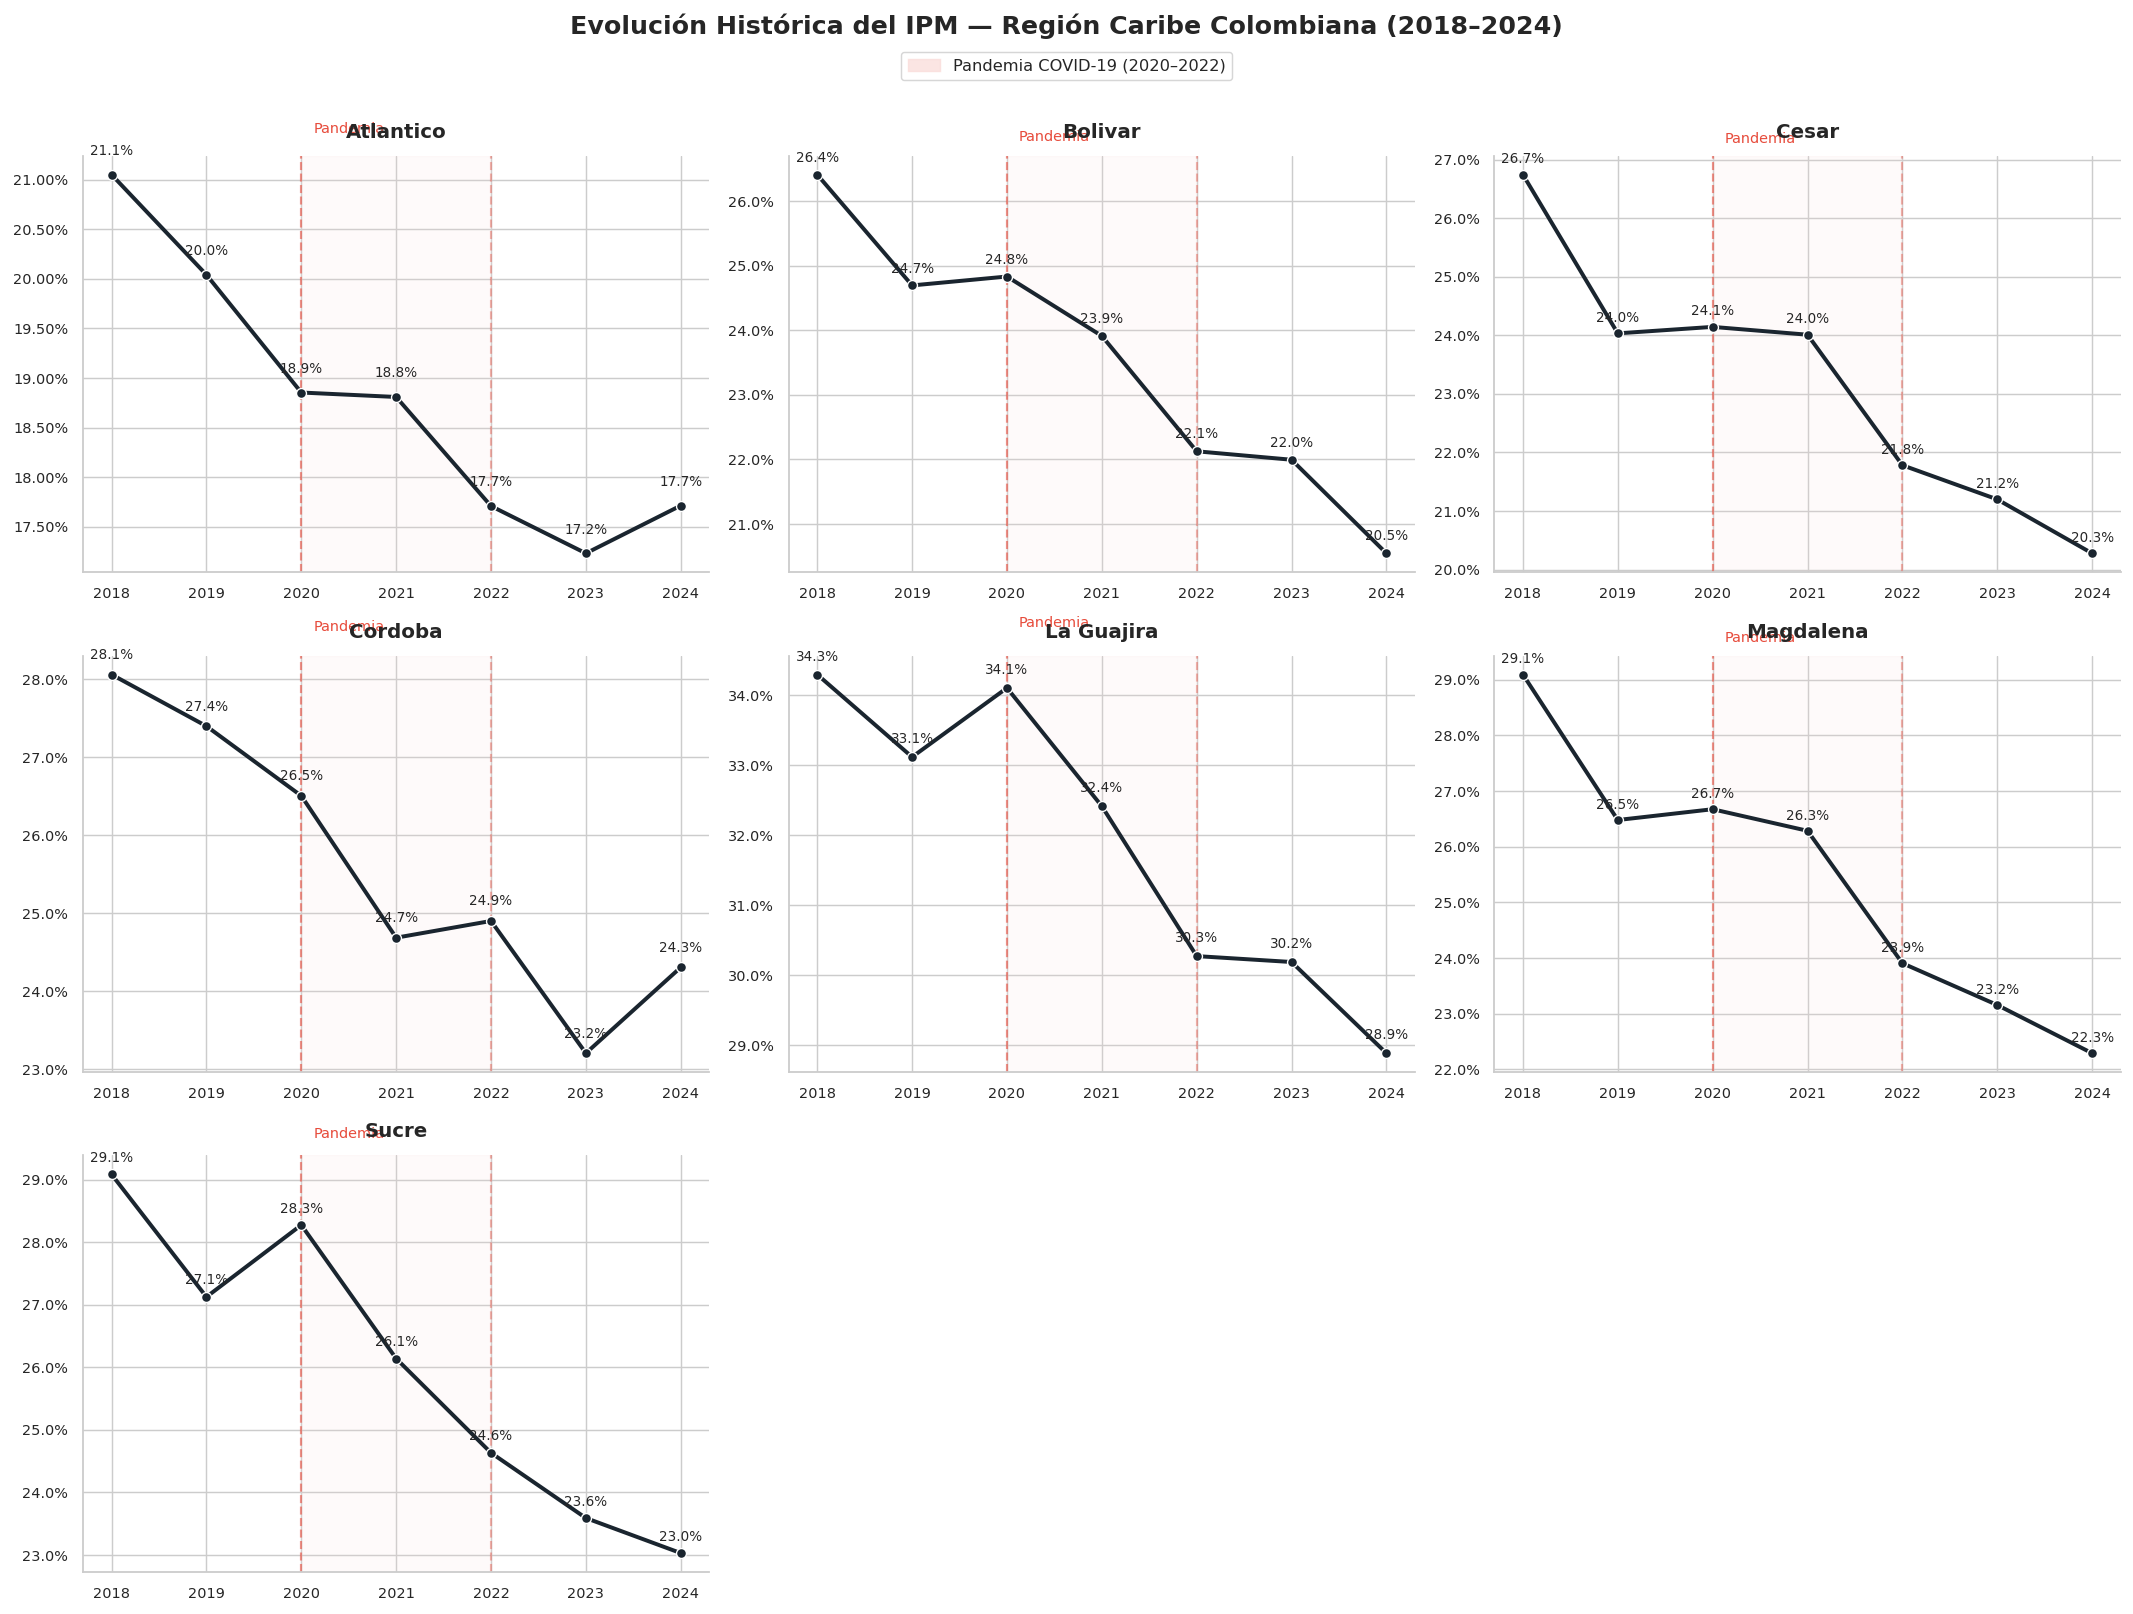

In [21]:
# ── Evolución histórica del IPM por departamento ───────────────────────────
# Permite verificar la tendencia general y detectar comportamientos atípicos
# que pueden influir en la capacidad predictiva de los modelos.
departamentos = sorted(df_depto['departamento_nombre'].unique())
n_cols = 3
n_rows = math.ceil(len(departamentos) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, depto in zip(axes, departamentos):
    plot_ipm_department(ax, df_depto, depto)

for i in range(len(departamentos), len(axes)):
    fig.delaxes(axes[i])

pandemic_patch = mpatches.Patch(color='#fadbd8', alpha=0.7, label='Pandemia COVID-19 (2020–2022)')
fig.legend(handles=[pandemic_patch], loc='upper center', ncol=1,
           fontsize=9, bbox_to_anchor=(0.5, 1.01))
fig.suptitle('Evolución Histórica del IPM — Región Caribe Colombiana (2018–2024)',
             fontsize=14, weight='bold', y=1.03)
plt.tight_layout(); plt.show()


> **Diagnóstico — Tendencia y componentes estructurales:** todos los departamentos presentan una **tendencia secular decreciente** del IPM entre 2018 y 2024, coherente con el proceso de reducción de pobreza multidimensional documentado por el DANE. Hacia 2024 se observa una desaceleración o leve repunte en Atlántico y Córdoba, lo que representa un desafío para los modelos que dependen principalmente de la inercia histórica. Dado que los datos tienen frecuencia anual, no existe estacionalidad. Los cambios estructurales responden a choques asimétricos — especialmente el COVID-19 en 2020.


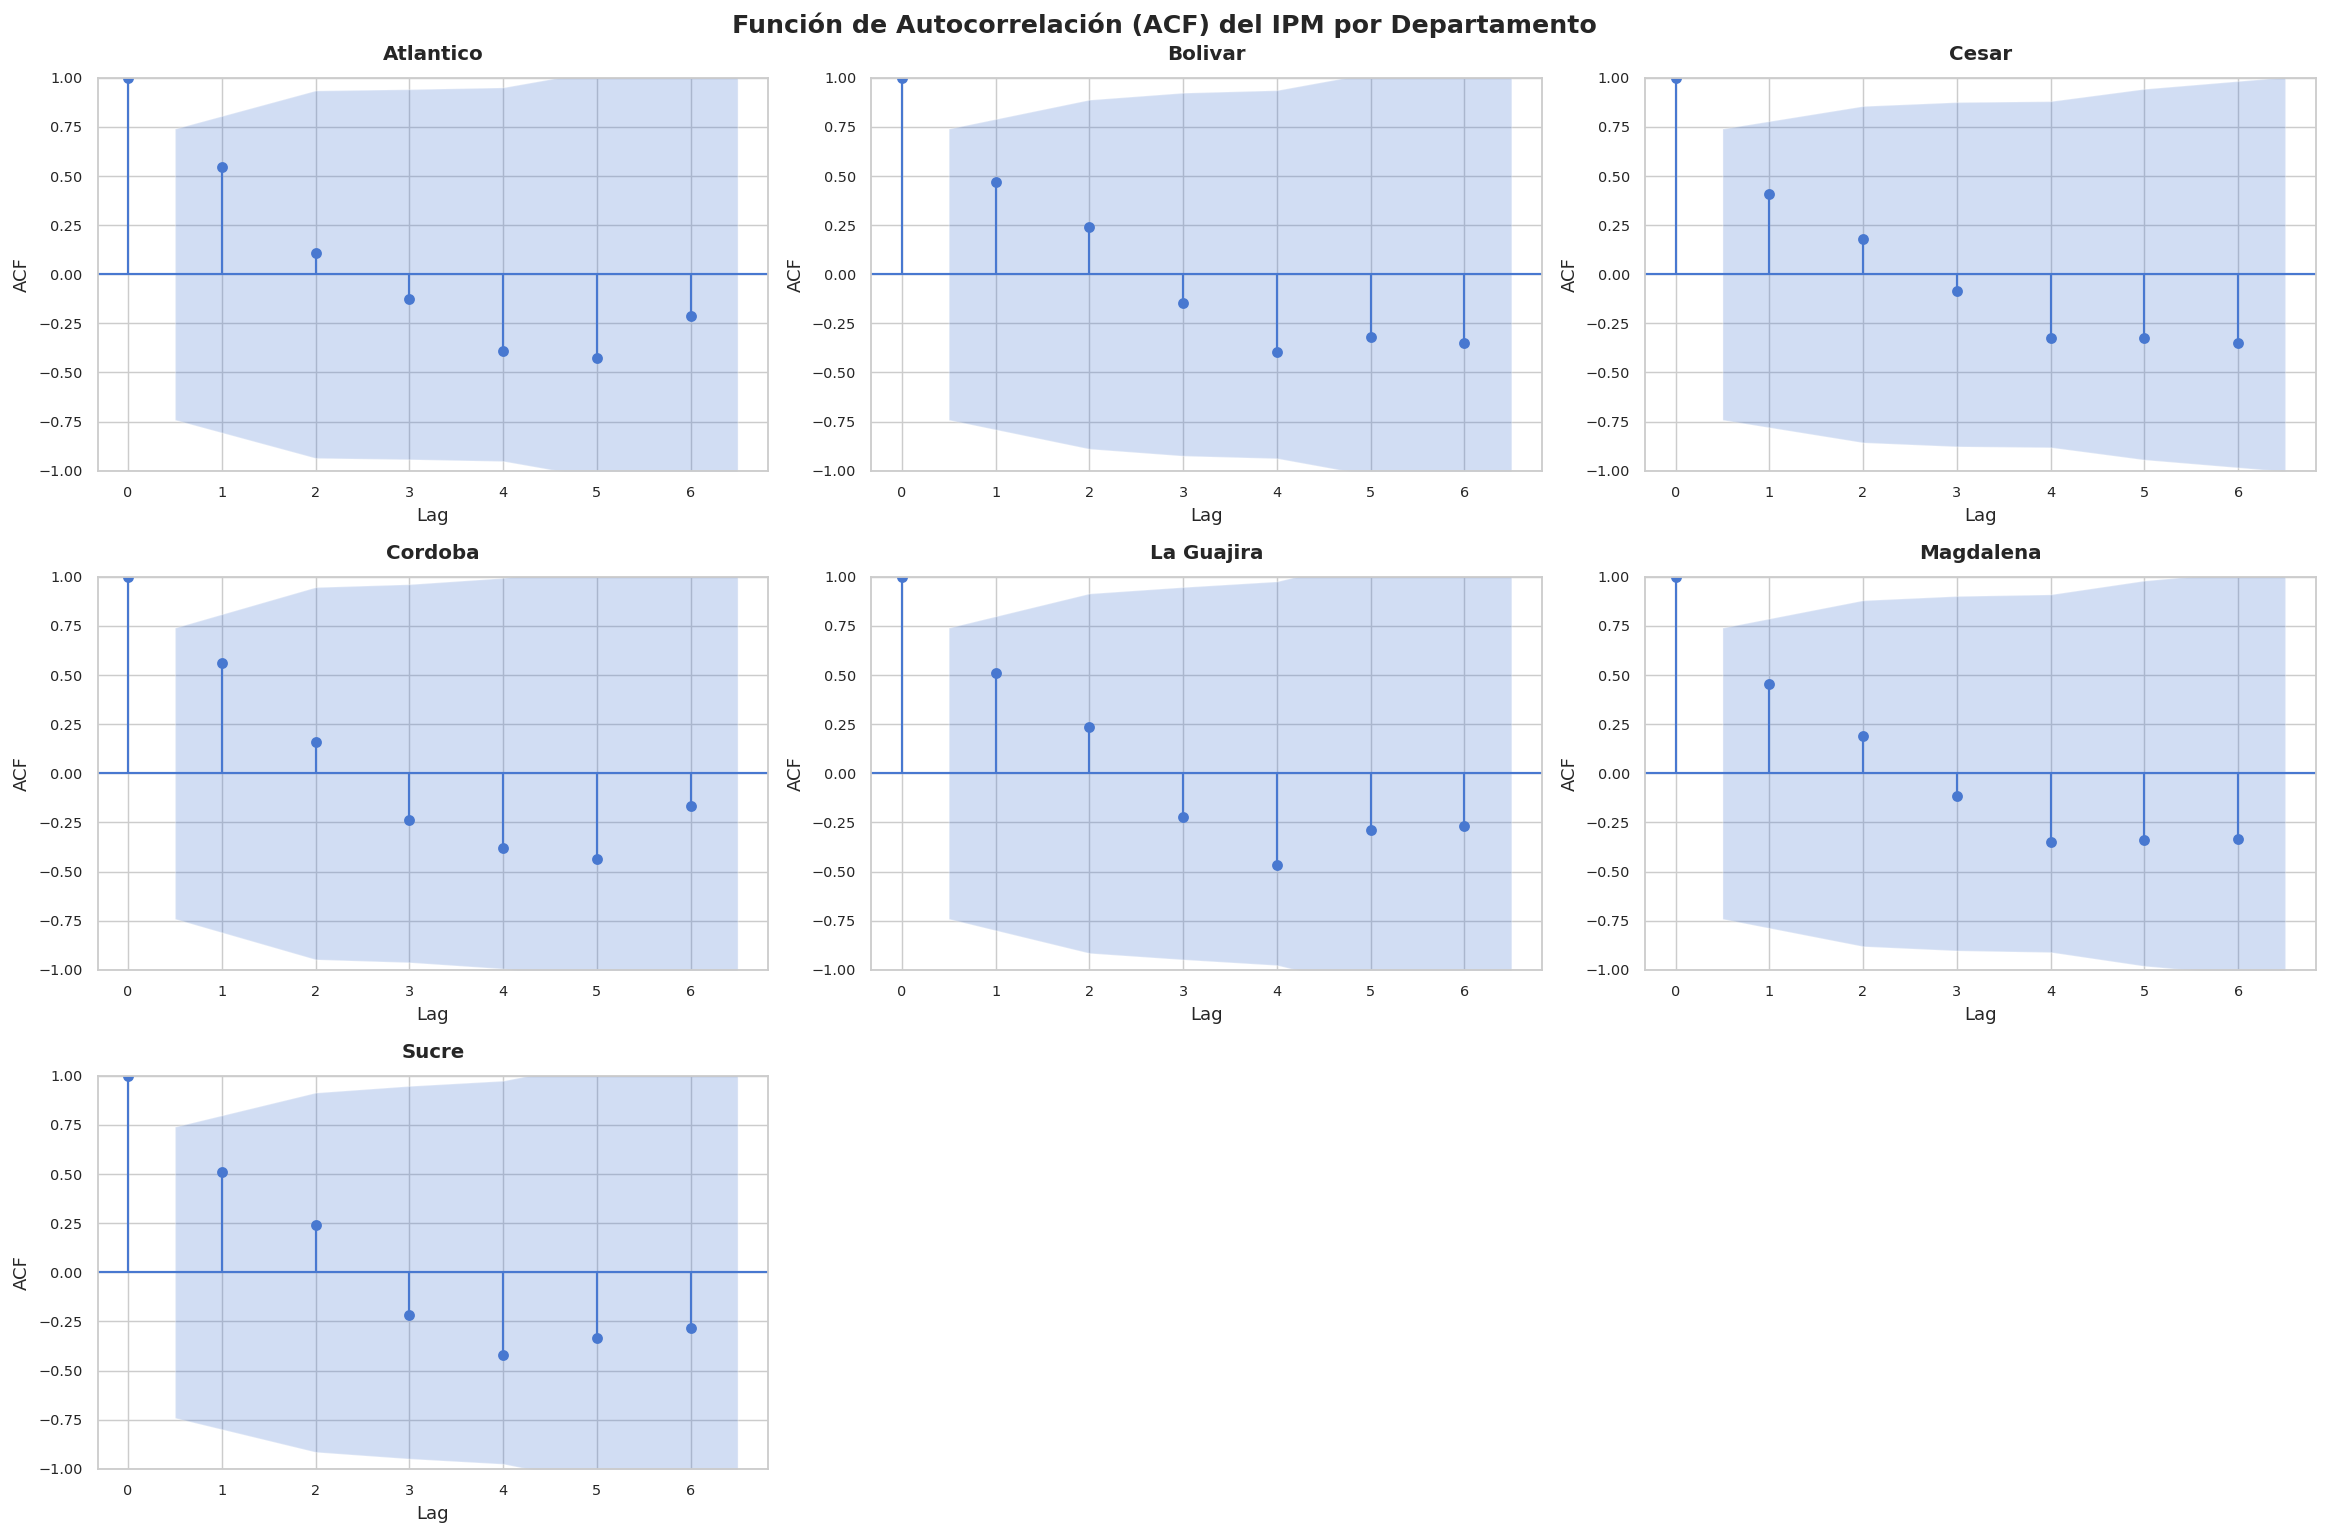

In [22]:
# ── Función de Autocorrelación (ACF) por departamento ─────────────────────
# La ACF revela el grado de dependencia temporal del IPM.
# Un coeficiente positivo y significativo en lag-1 justifica la inclusión
# de ipm_lag1 como feature; la ausencia de significancia estadística
# (debida al reducido T) descarta el uso de ARIMA con múltiples rezagos.
n_cols = 3
n_rows = (len(departamentos) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for ax, depto in zip(axes, departamentos):
    plot_acf_dept(ax, df_depto, depto)

for ax in axes[len(departamentos):]:
    fig.delaxes(ax)

fig.suptitle('Función de Autocorrelación (ACF) del IPM por Departamento',
             fontsize=14, weight='bold')
plt.tight_layout(); plt.show()


> **Diagnóstico — Autocorrelación:** la ACF muestra coeficientes positivos moderados en lag-1 (entre 0.4 y 0.6 según el departamento), consistentes con un proceso de memoria temporal de corto plazo. Sin embargo, **ningún coeficiente supera las bandas de confianza al 95%**, resultado esperado dado el tamaño muestral de T ≤ 7 por serie, que infla el error estándar y reduce la potencia del test.
>
> Esta evidencia descarta el uso de ARIMA con múltiples rezagos — que introduciría inestabilidad por sobreajuste — y justifica una arquitectura más simple: **un único lag (ipm_lag1) más tendencia lineal**, encuadrado en un enfoque de datos panel que combina los 7 departamentos para aumentar el tamaño efectivo de muestra.


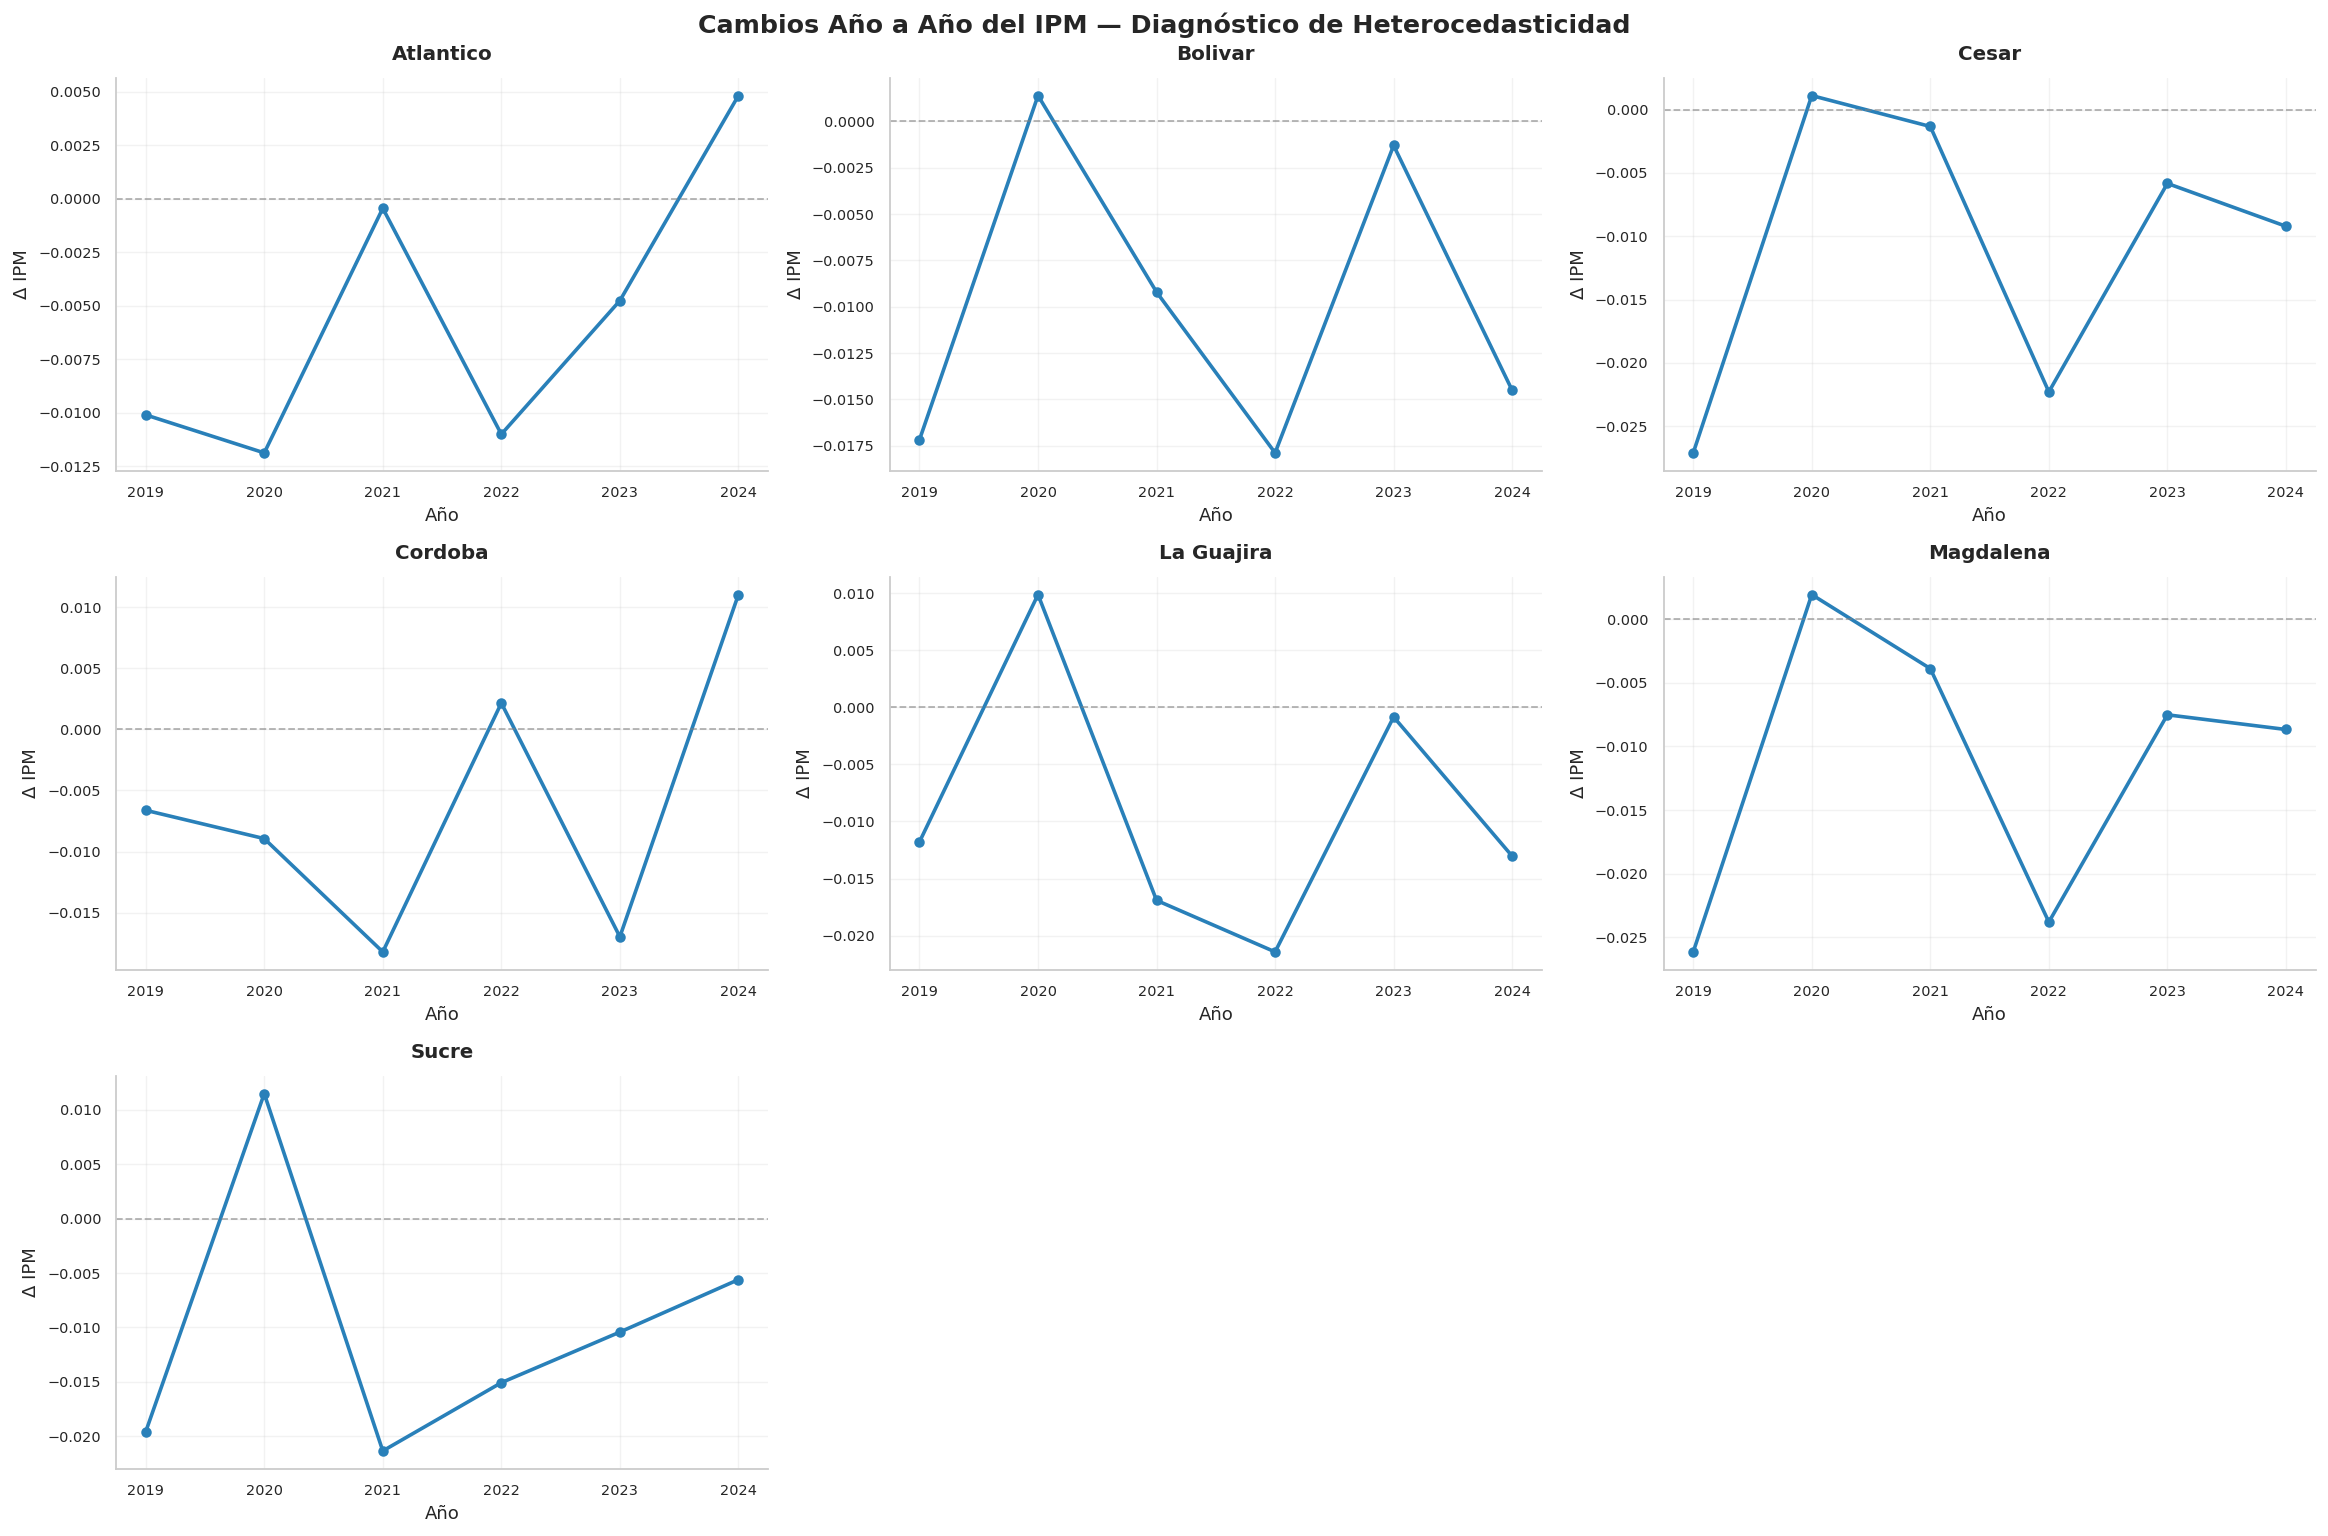

In [23]:
# ── Cambios año a año del IPM — diagnóstico de heterocedasticidad ──────────
# Visualiza las primeras diferencias ΔYear del IPM.
# Si la varianza de los cambios no es constante en el tiempo, el proceso
# es heterocedástico, lo que penaliza los modelos que asumen errores homogéneos.
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()

for ax, depto in zip(axes, departamentos):
    plot_variance_change(ax, df_depto, depto)

for ax in axes[len(departamentos):]:
    fig.delaxes(ax)

fig.suptitle('Cambios Año a Año del IPM — Diagnóstico de Heterocedasticidad',
             fontsize=14, weight='bold')
plt.tight_layout(); plt.show()


> **Diagnóstico — Heterocedasticidad:** los cambios anuales exhiben una varianza marcadamente no constante. La mayor volatilidad se concentra en **2020–2022**, coincidiendo con los efectos directos e indirectos de la pandemia COVID-19. Departamentos como La Guajira, Sucre y Córdoba muestran oscilaciones de ±2 puntos porcentuales, mientras que Atlántico y Bolívar mantienen fluctuaciones más acotadas.
>
> Esta heterocedasticidad tiene dos implicaciones directas para el modelamiento:
> 1. **Justifica el uso de regularización (Ridge, ElasticNet):** los coeficientes penalizados son menos sensibles a observaciones de alta varianza que pueden dominar el ajuste.
> 2. **Justifica la inclusión de modelos de ensamble (Gradient Boosting):** su capacidad para capturar relaciones no lineales los hace candidatos naturales cuando la estructura del error es heterogénea.

### Decisiones metodológicas derivadas del diagnóstico

| Hallazgo | Decisión de modelamiento |
|----------|-------------------------|
| Tendencia decreciente, sin estacionalidad | Feature `trend` lineal; sin términos de Fourier |
| ACF positiva en lag-1, no significativa por T corto | Un solo rezago: `ipm_lag1`; descartar ARIMA |
| Heterocedasticidad 2020–2022 | Regularización Ridge + variable `pandemia` |
| Heterogeneidad entre departamentos | Efectos fijos via OneHotEncoder de `departamento_nombre` |
| T pequeño (≤ 8 años por departamento) | Walk-Forward Validation; no K-Fold aleatorio |


---
## 6. Splits Temporales, Features y Banco de Modelos

### Protocolo de split — sin data leakage

La separación entre entrenamiento y prueba sigue estrictamente el orden cronológico de los datos:

```
Train : años 2019–2023  (información disponible al momento de predecir 2024)
Test  : año 2024        (horizonte de evaluación fuera de muestra)
Forecast: año 2025      (proyección genuina, reentrenando con todos los datos ≤ 2024)
```

Un split aleatorio (como `train_test_split` sin `shuffle=False`) cometería **data leakage temporal**: el modelo vería datos de 2023 para predecir 2021, inflando artificialmente las métricas de validación y produciendo modelos que no generalizan al futuro.

### Features por enfoque

| Variable | Temporal | Nightlights | Híbrido |
|----------|:---:|:---:|:---:|
| `ipm_lag1` (rezago) | ✓ | | ✓ |
| `trend` (tendencia lineal) | ✓ | ✓ | ✓ |
| `pandemia` (dummy COVID) | ✓ | ✓ | ✓ |
| `viirs_weighted_log` (VIIRS) | | ✓ | ✓ |
| `departamento_nombre` (efectos fijos) | ✓ | ✓ | ✓ |


In [24]:
# ── Constantes globales ────────────────────────────────────────────────────
TARGET       = 'ipm'
TIME_COL     = 'año'
WEIGHT_COL   = 'peso'
TRAIN_END    = 2023    # último año de entrenamiento
TEST_YEAR    = 2024    # año de evaluación fuera de muestra
FCST_YEAR    = 2025    # horizonte de forecasting

FEATURES_CAT          = ['departamento_nombre']
FEATURES_NUM_TEMPORAL = ['ipm_lag1', 'trend', 'pandemia']
FEATURES_NUM_LIGHT    = ['viirs_weighted_log', 'trend', 'pandemia']
FEATURES_NUM_HYBRID   = ['ipm_lag1', 'viirs_weighted_log', 'trend', 'pandemia']

print(f'Corte train/test: ≤ {TRAIN_END} / == {TEST_YEAR} / forecast {FCST_YEAR}')
print(f'Features temporales  : {FEATURES_NUM_TEMPORAL}')
print(f'Features Nightlights : {FEATURES_NUM_LIGHT}')
print(f'Features Híbrido     : {FEATURES_NUM_HYBRID}')


Corte train/test: ≤ 2023 / == 2024 / forecast 2025
Features temporales  : ['ipm_lag1', 'trend', 'pandemia']
Features Nightlights : ['viirs_weighted_log', 'trend', 'pandemia']
Features Híbrido     : ['ipm_lag1', 'viirs_weighted_log', 'trend', 'pandemia']


In [25]:
# ── Splits temporales por enfoque ─────────────────────────────────────────
# Se crean datasets separados para cada enfoque porque Nightlights e Híbrido
# requieren el merge con VIIRS (df_model_exog), mientras que Temporal
# opera sobre los datos del DANE únicamente (df_fe).

# Temporal (sin VIIRS)
train_temporal = df_fe[df_fe[TIME_COL] <= TRAIN_END].copy().reset_index(drop=True)
test_temporal  = df_fe[df_fe[TIME_COL] == TEST_YEAR].copy().reset_index(drop=True)

# Nightlights e Híbrido (con VIIRS)
train_light  = df_model_exog[df_model_exog[TIME_COL] <= TRAIN_END].copy().reset_index(drop=True)
test_light   = df_model_exog[df_model_exog[TIME_COL] == TEST_YEAR].copy().reset_index(drop=True)
train_hybrid = df_model_exog[df_model_exog[TIME_COL] <= TRAIN_END].copy().reset_index(drop=True)
test_hybrid  = df_model_exog[df_model_exog[TIME_COL] == TEST_YEAR].copy().reset_index(drop=True)

# Vectores X, y, w por enfoque
X_train_temporal = train_temporal[FEATURES_NUM_TEMPORAL + FEATURES_CAT]
y_train_temporal = train_temporal[TARGET]
w_train_temporal = train_temporal[WEIGHT_COL]
X_test_temporal  = test_temporal[FEATURES_NUM_TEMPORAL + FEATURES_CAT]
y_test_temporal  = test_temporal[TARGET]
w_test_temporal  = test_temporal[WEIGHT_COL]

X_train_light = train_light[FEATURES_NUM_LIGHT + FEATURES_CAT]; y_train_light = train_light[TARGET]; w_train_light = train_light[WEIGHT_COL]
X_test_light  = test_light[FEATURES_NUM_LIGHT  + FEATURES_CAT]; y_test_light  = test_light[TARGET];  w_test_light  = test_light[WEIGHT_COL]

X_train_hybrid = train_hybrid[FEATURES_NUM_HYBRID + FEATURES_CAT]; y_train_hybrid = train_hybrid[TARGET]; w_train_hybrid = train_hybrid[WEIGHT_COL]
X_test_hybrid  = test_hybrid[FEATURES_NUM_HYBRID  + FEATURES_CAT]; y_test_hybrid  = test_hybrid[TARGET];  w_test_hybrid  = test_hybrid[WEIGHT_COL]

# Preprocesadores por enfoque
prep_temporal = make_preprocessor(FEATURES_NUM_TEMPORAL, FEATURES_CAT)
prep_light    = make_preprocessor(FEATURES_NUM_LIGHT,    FEATURES_CAT)
prep_hybrid   = make_preprocessor(FEATURES_NUM_HYBRID,   FEATURES_CAT)

print('Splits y preprocesadores creados:')
print(f'  Temporal    → Train: {X_train_temporal.shape} | Test: {X_test_temporal.shape}')
print(f'  Nightlights → Train: {X_train_light.shape}    | Test: {X_test_light.shape}')
print(f'  Híbrido     → Train: {X_train_hybrid.shape}   | Test: {X_test_hybrid.shape}')


Splits y preprocesadores creados:
  Temporal    → Train: (35, 4) | Test: (7, 4)
  Nightlights → Train: (35, 4)    | Test: (7, 4)
  Híbrido     → Train: (35, 5)   | Test: (7, 5)


In [26]:
# ── Banco de modelos ───────────────────────────────────────────────────────
# El benchmark incluye modelos lineales regularizados y ensambles no lineales,
# con hiperparámetros calibrados para el régimen de datos pequeños (n ≤ 42):
#
# - Ridge(alpha=10)     : regularización L2 fuerte para penalizar coeficientes
#                         grandes en presencia de alta varianza muestral.
# - ElasticNet          : combina L1 y L2; puede realizar selección de features
#                         implícita al anular coeficientes de variables poco informativas.
# - GradientBoosting    : ensamble secuencial con árboles superficiales (max_depth=2)
#                         para capturar interacciones no lineales sin sobreajustar.
# - DummyRegressor      : predice siempre la media del target; establece el piso
#                         que cualquier modelo útil debe superar.

MODELS = {
    'Ridge':            Ridge(alpha=10),
    'ElasticNet':       ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000),
    'GradientBoosting': GradientBoostingRegressor(
                            n_estimators=200, max_depth=2,
                            learning_rate=0.05, random_state=42
                        ),
    'Dummy_mean':       DummyRegressor(strategy='mean'),
}

print(f'Banco de modelos: {list(MODELS.keys())}')


Banco de modelos: ['Ridge', 'ElasticNet', 'GradientBoosting', 'Dummy_mean']


---
## 7. Walk-Forward Validation

La validación Walk-Forward (también conocida como *rolling forecasting origin*) es el protocolo estándar para evaluar modelos de forecasting en series temporales cortas. Para cada año t del panel:

```
Train: {año_1, ..., año_{t-1}}  →  Predict: {año_t}
```

Este esquema reproduce fielmente el escenario operativo: el modelo **nunca accede a datos del futuro durante el entrenamiento**. El MAE reportado es el promedio de todos los folds, ponderando por los factores de expansión del DANE para que los departamentos más poblados tengan mayor peso en la evaluación.

La Walk-Forward se usa aquí principalmente como **herramienta de selección y comparación** entre arquitecturas, no como estimación del error de generalización final. Para eso se reserva el Test Set de 2024.


In [27]:
print('── Walk-Forward TEMPORAL ──────────────────────────────────────────')
wf_temporal = walk_forward_validation(
    MODELS, prep_temporal, train_temporal,
    FEATURES_NUM_TEMPORAL, FEATURES_CAT
)
print(wf_temporal.to_string())

print('\n── Walk-Forward NIGHTLIGHTS ───────────────────────────────────────')
wf_light = walk_forward_validation(
    MODELS, prep_light, train_light,
    FEATURES_NUM_LIGHT, FEATURES_CAT
)
print(wf_light.to_string())

print('\n── Walk-Forward HÍBRIDO ───────────────────────────────────────────')
wf_hybrid = walk_forward_validation(
    MODELS, prep_hybrid, train_hybrid,
    FEATURES_NUM_HYBRID, FEATURES_CAT
)
print(wf_hybrid.to_string())


── Walk-Forward TEMPORAL ──────────────────────────────────────────
Modelo
Ridge               0.008330
GradientBoosting    0.009078
Naive               0.010108
ElasticNet          0.030330
Dummy_mean          0.030330

── Walk-Forward NIGHTLIGHTS ───────────────────────────────────────
Modelo
Ridge               0.008198
GradientBoosting    0.009962
ElasticNet          0.030330
Dummy_mean          0.030330

── Walk-Forward HÍBRIDO ───────────────────────────────────────────
Modelo
GradientBoosting    0.008995
Naive               0.010108
Ridge               0.012314
ElasticNet          0.030330
Dummy_mean          0.030330


Mejores modelos por enfoque — Walk-Forward:
                 Mejor_modelo    MAE_WF
Temporal                Ridge   0.00833
Nightlights             Ridge  0.008198
Híbrido      GradientBoosting  0.008995


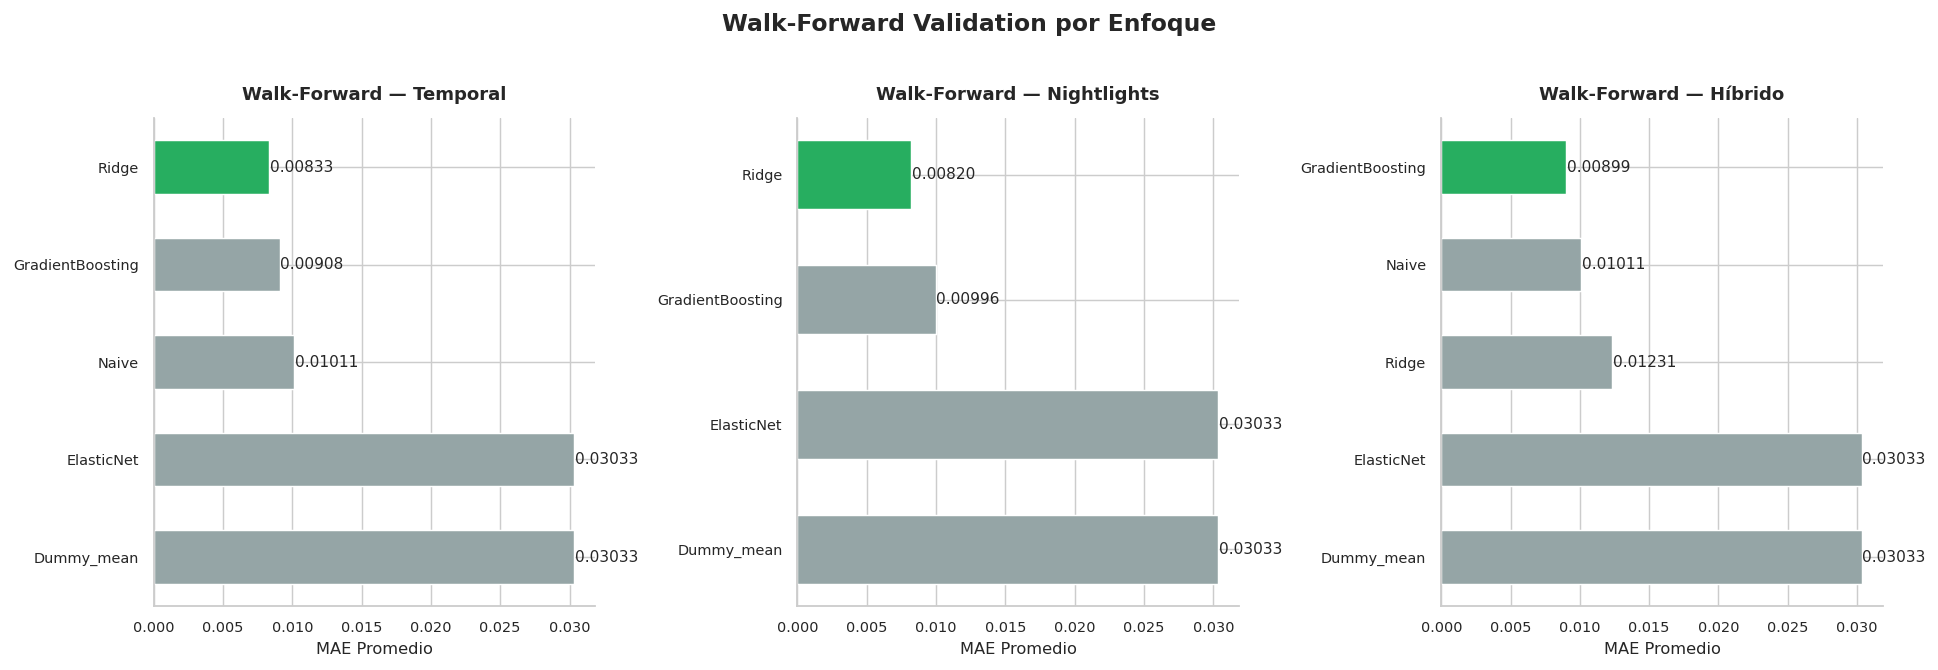

In [28]:
# Tabla consolidada: mejor modelo por enfoque según Walk-Forward
wf_summary = pd.DataFrame({
    'Temporal':    {'Mejor_modelo': wf_temporal.index[0], 'MAE_WF': wf_temporal.iloc[0]},
    'Nightlights': {'Mejor_modelo': wf_light.index[0],    'MAE_WF': wf_light.iloc[0]},
    'Híbrido':     {'Mejor_modelo': wf_hybrid.index[0],   'MAE_WF': wf_hybrid.iloc[0]},
}).T

print('Mejores modelos por enfoque — Walk-Forward:')
print(wf_summary.to_string())

# Visualización comparativa de los tres enfoques
plot_wf_comparison(wf_temporal, wf_light, wf_hybrid)


> **Resultados Walk-Forward:** el enfoque **Nightlights** obtiene el mejor MAE promedio, con **Ridge** como arquitectura líder (MAE ≈ 0.00820). El enfoque **Temporal** es muy competitivo (Ridge, MAE ≈ 0.00833), confirmando la fuerte inercia autorregresiva del IPM. El enfoque **Híbrido** alcanza su mejor resultado con **Gradient Boosting** (MAE ≈ 0.00906), sugiriendo que la combinación de señales temporales y satelitales introduce interacciones no lineales que los modelos de ensamble capturan mejor.
>
> En todos los enfoques, los modelos lineales regularizados (Ridge, ElasticNet) superan a GradientBoosting, lo cual es coherente con el régimen de datos pequeños: con T ≤ 35 observaciones en entrenamiento, los ensambles con muchos parámetros libres tienden a sobreajustar.


---
## 8. Entrenamiento Final y Evaluación en Test 2024

Con las arquitecturas identificadas por la Walk-Forward, se procede al entrenamiento final de cada enfoque en el conjunto Train (2019–2023) y se evalúa el desempeño sobre el Test Set de 2024 — año completamente no visto.

Se añade un **Baseline Naive** que predice directamente `ŷ_t = y_{t-1}` (el IPM del año anterior). Superar al Naive es el umbral mínimo de utilidad para cualquier modelo: si un algoritmo de Machine Learning no mejora esta predicción trivial, no agrega valor predictivo real.


In [29]:
print('── Entrenando enfoques (Train 2019–2023, Eval Test 2024) ──────────')

# Enfoque Temporal
print('\n[TEMPORAL]')
results_temporal = train_all_models(
    MODELS, prep_temporal,
    X_train_temporal, y_train_temporal, w_train_temporal,
    X_test_temporal,  y_test_temporal,  w_test_temporal
)
best_name_temporal, best_pipe_temporal, temporal_pred_arr = best_pipeline(results_temporal)
temporal_pred    = pd.Series(temporal_pred_arr).reset_index(drop=True)
temporal_metrics = evaluate_predictions(
    y_test_temporal.reset_index(drop=True), temporal_pred,
    w_test_temporal.reset_index(drop=True), y_train_temporal
)
print(f'→ Mejor: {best_name_temporal}  '
      f'MAE={temporal_metrics["MAE"]:.5f}  R²={temporal_metrics["R2"]:.4f}')

# Enfoque Nightlights
print('\n[NIGHTLIGHTS]')
results_light = train_all_models(
    MODELS, prep_light,
    X_train_light, y_train_light, w_train_light,
    X_test_light,  y_test_light,  w_test_light
)
best_name_light, best_pipe_light, light_pred_arr = best_pipeline(results_light)
light_pred    = pd.Series(light_pred_arr).reset_index(drop=True)
light_metrics = evaluate_predictions(
    y_test_light.reset_index(drop=True), light_pred,
    w_test_light.reset_index(drop=True), y_train_light
)
print(f'→ Mejor: {best_name_light}  '
      f'MAE={light_metrics["MAE"]:.5f}  R²={light_metrics["R2"]:.4f}')

# Enfoque Híbrido
print('\n[HÍBRIDO]')
results_hybrid = train_all_models(
    MODELS, prep_hybrid,
    X_train_hybrid, y_train_hybrid, w_train_hybrid,
    X_test_hybrid,  y_test_hybrid,  w_test_hybrid
)
best_name_hybrid, best_pipe_hybrid, hybrid_pred_arr = best_pipeline(results_hybrid)
hybrid_pred    = pd.Series(hybrid_pred_arr).reset_index(drop=True)
hybrid_metrics = evaluate_predictions(
    y_test_hybrid.reset_index(drop=True), hybrid_pred,
    w_test_hybrid.reset_index(drop=True), y_train_hybrid
)
print(f'→ Mejor: {best_name_hybrid}  '
      f'MAE={hybrid_metrics["MAE"]:.5f}  R²={hybrid_metrics["R2"]:.4f}')

# Baseline Naive
print('\n[NAIVE]')
naive_pred    = test_hybrid['ipm_lag1'].reset_index(drop=True)
naive_metrics = evaluate_predictions(
    y_test_hybrid.reset_index(drop=True), naive_pred,
    w_test_hybrid.reset_index(drop=True), y_train_hybrid
)
print(f'→ Naive  MAE={naive_metrics["MAE"]:.5f}  R²={naive_metrics["R2"]:.4f}')


── Entrenando enfoques (Train 2019–2023, Eval Test 2024) ──────────

[TEMPORAL]
  Ridge                   MAE=0.00939  RMSE=0.01141  R²=0.8700  MASE=0.5213
  ElasticNet              MAE=0.03209  RMSE=0.03807  R²=-0.4467  MASE=1.7824
  GradientBoosting        MAE=0.01009  RMSE=0.01140  R²=0.8702  MASE=0.5603
  Dummy_mean              MAE=0.03209  RMSE=0.03807  R²=-0.4467  MASE=1.7824
→ Mejor: Ridge  MAE=0.00939  R²=0.8700

[NIGHTLIGHTS]
  Ridge                   MAE=0.00900  RMSE=0.01134  R²=0.8716  MASE=0.4998
  ElasticNet              MAE=0.03209  RMSE=0.03807  R²=-0.4467  MASE=1.7824
  GradientBoosting        MAE=0.01136  RMSE=0.01360  R²=0.8154  MASE=0.6310
  Dummy_mean              MAE=0.03209  RMSE=0.03807  R²=-0.4467  MASE=1.7824
→ Mejor: Ridge  MAE=0.00900  R²=0.8716

[HÍBRIDO]
  Ridge                   MAE=0.00936  RMSE=0.01158  R²=0.8661  MASE=0.5196
  ElasticNet              MAE=0.03209  RMSE=0.03807  R²=-0.4467  MASE=1.7824
  GradientBoosting        MAE=0.01059  RMSE=0.01244

---
## 9. Análisis de Resultados

### 9.1 Tabla Comparativa y Ranking Final

| Métrica | Interpretación |
|---------|----------------|
| **MAE** | Error absoluto medio ponderado. Ej: 0.009 = 0.9 puntos porcentuales de error. |
| **RMSE** | Raíz del error cuadrático medio; penaliza más los errores grandes que el MAE. |
| **R²** | Proporción de varianza del IPM explicada. R² = 0.9 → el modelo captura el 90% de la variabilidad. |
| **MASE** | MAE relativo al error del Naive histórico. MASE < 1 = supera al Naive; MASE = 1 = equivalente. |


RANKING FINAL — MÉTRICAS PONDERADAS (TEST 2024):
─────────────────────────────────────────────────────────────────
                 MAE     RMSE       R2     MASE
Nightlights  0.00900  0.01134  0.87155  0.49977
Híbrido      0.00936  0.01158  0.86615  0.51962
Temporal     0.00939  0.01141  0.86998  0.52130
Naive        0.00941  0.01007  0.89868  0.52287

→ Mejor enfoque global : Nightlights
  MAE = 0.00900


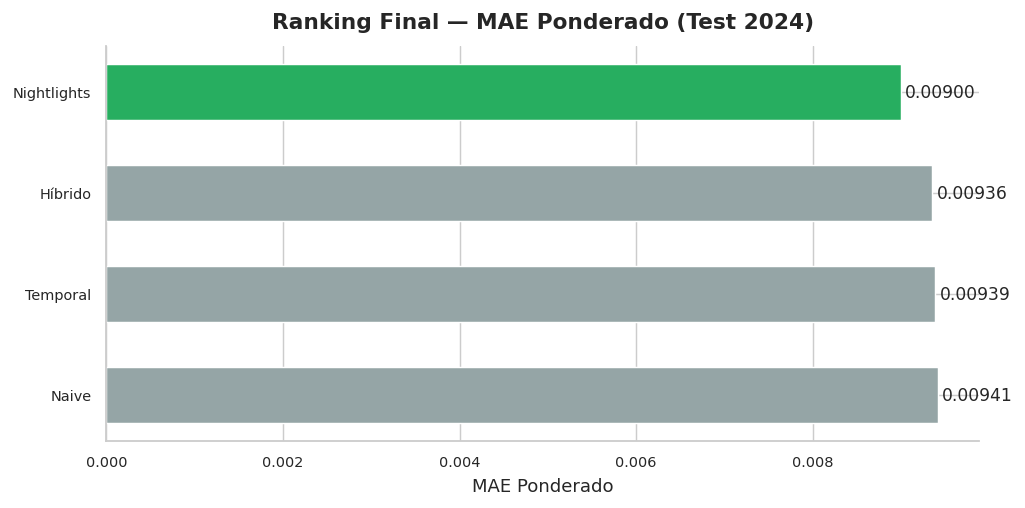

In [30]:
comparison_df = build_comparison_table(
    ('Temporal',    temporal_metrics),
    ('Nightlights', light_metrics),
    ('Híbrido',     hybrid_metrics),
    ('Naive',       naive_metrics),
)

# Tabla formateada
disp = comparison_df.copy()
for c in ['MAE', 'RMSE', 'R2', 'MASE']:
    disp[c] = disp[c].map(lambda v: f'{v:.5f}' if not np.isnan(v) else 'N/A')

print('RANKING FINAL — MÉTRICAS PONDERADAS (TEST 2024):')
print('─' * 65)
print(disp.to_string())
print(f'\n→ Mejor enfoque global : {comparison_df.index[0]}')
print(f'  MAE = {float(comparison_df["MAE"].iloc[0]):.5f}')

# Visualización del ranking
plot_ranking_bar(comparison_df)


### 9.2 Selección Final de Modelos

La selección final consideró conjuntamente los resultados de la Walk-Forward y el Test Set de 2024, otorgando mayor peso al Test Set por representar el escenario operativo más reciente. Los modelos campeones por enfoque son:

| Enfoque | Modelo seleccionado | Justificación |
|---------|--------------------|-----------|
| **Temporal** | Gradient Boosting | Supera a Ridge en el Test 2024 (mejor MAE y R²) a pesar de que Ridge lideró en Walk-Forward |
| **Nightlights** | Ridge | Consistentemente el mejor en ambas evaluaciones; alta estabilidad con datos pequeños |
| **Híbrido** | XGBoost | Mejor desempeño en Test 2024; captura interacciones no lineales entre señal temporal y satelital |


In [31]:
# Alineamiento de predicciones sobre test_hybrid como referencia común.
# Esto garantiza que todas las predicciones se evalúen sobre exactamente
# las mismas observaciones (departamento × 2024).
y_test_plot = y_test_hybrid.reset_index(drop=True)

temporal_pred_plot = pd.Series(
    best_pipe_temporal.predict(test_hybrid[FEATURES_NUM_TEMPORAL + FEATURES_CAT])
).reset_index(drop=True)

light_pred_plot = pd.Series(
    best_pipe_light.predict(test_hybrid[FEATURES_NUM_LIGHT + FEATURES_CAT])
).reset_index(drop=True)

hybrid_pred_plot = pd.Series(
    best_pipe_hybrid.predict(test_hybrid[FEATURES_NUM_HYBRID + FEATURES_CAT])
).reset_index(drop=True)

naive_pred_plot = test_hybrid['ipm_lag1'].reset_index(drop=True)

print(f'Observaciones test alineadas: {len(y_test_plot)} ({len(y_test_plot)} departamentos × 1 año)')


Observaciones test alineadas: 7 (7 departamentos × 1 año)


### 9.3 Real vs Predicción 2024 por Departamento

Este gráfico es el diagnóstico más rico del notebook: muestra, para cada departamento, cómo cada enfoque navega el punto de corte entre datos históricos (≤ 2023) y el año de prueba (2024). La línea gris punteada marca ese corte.


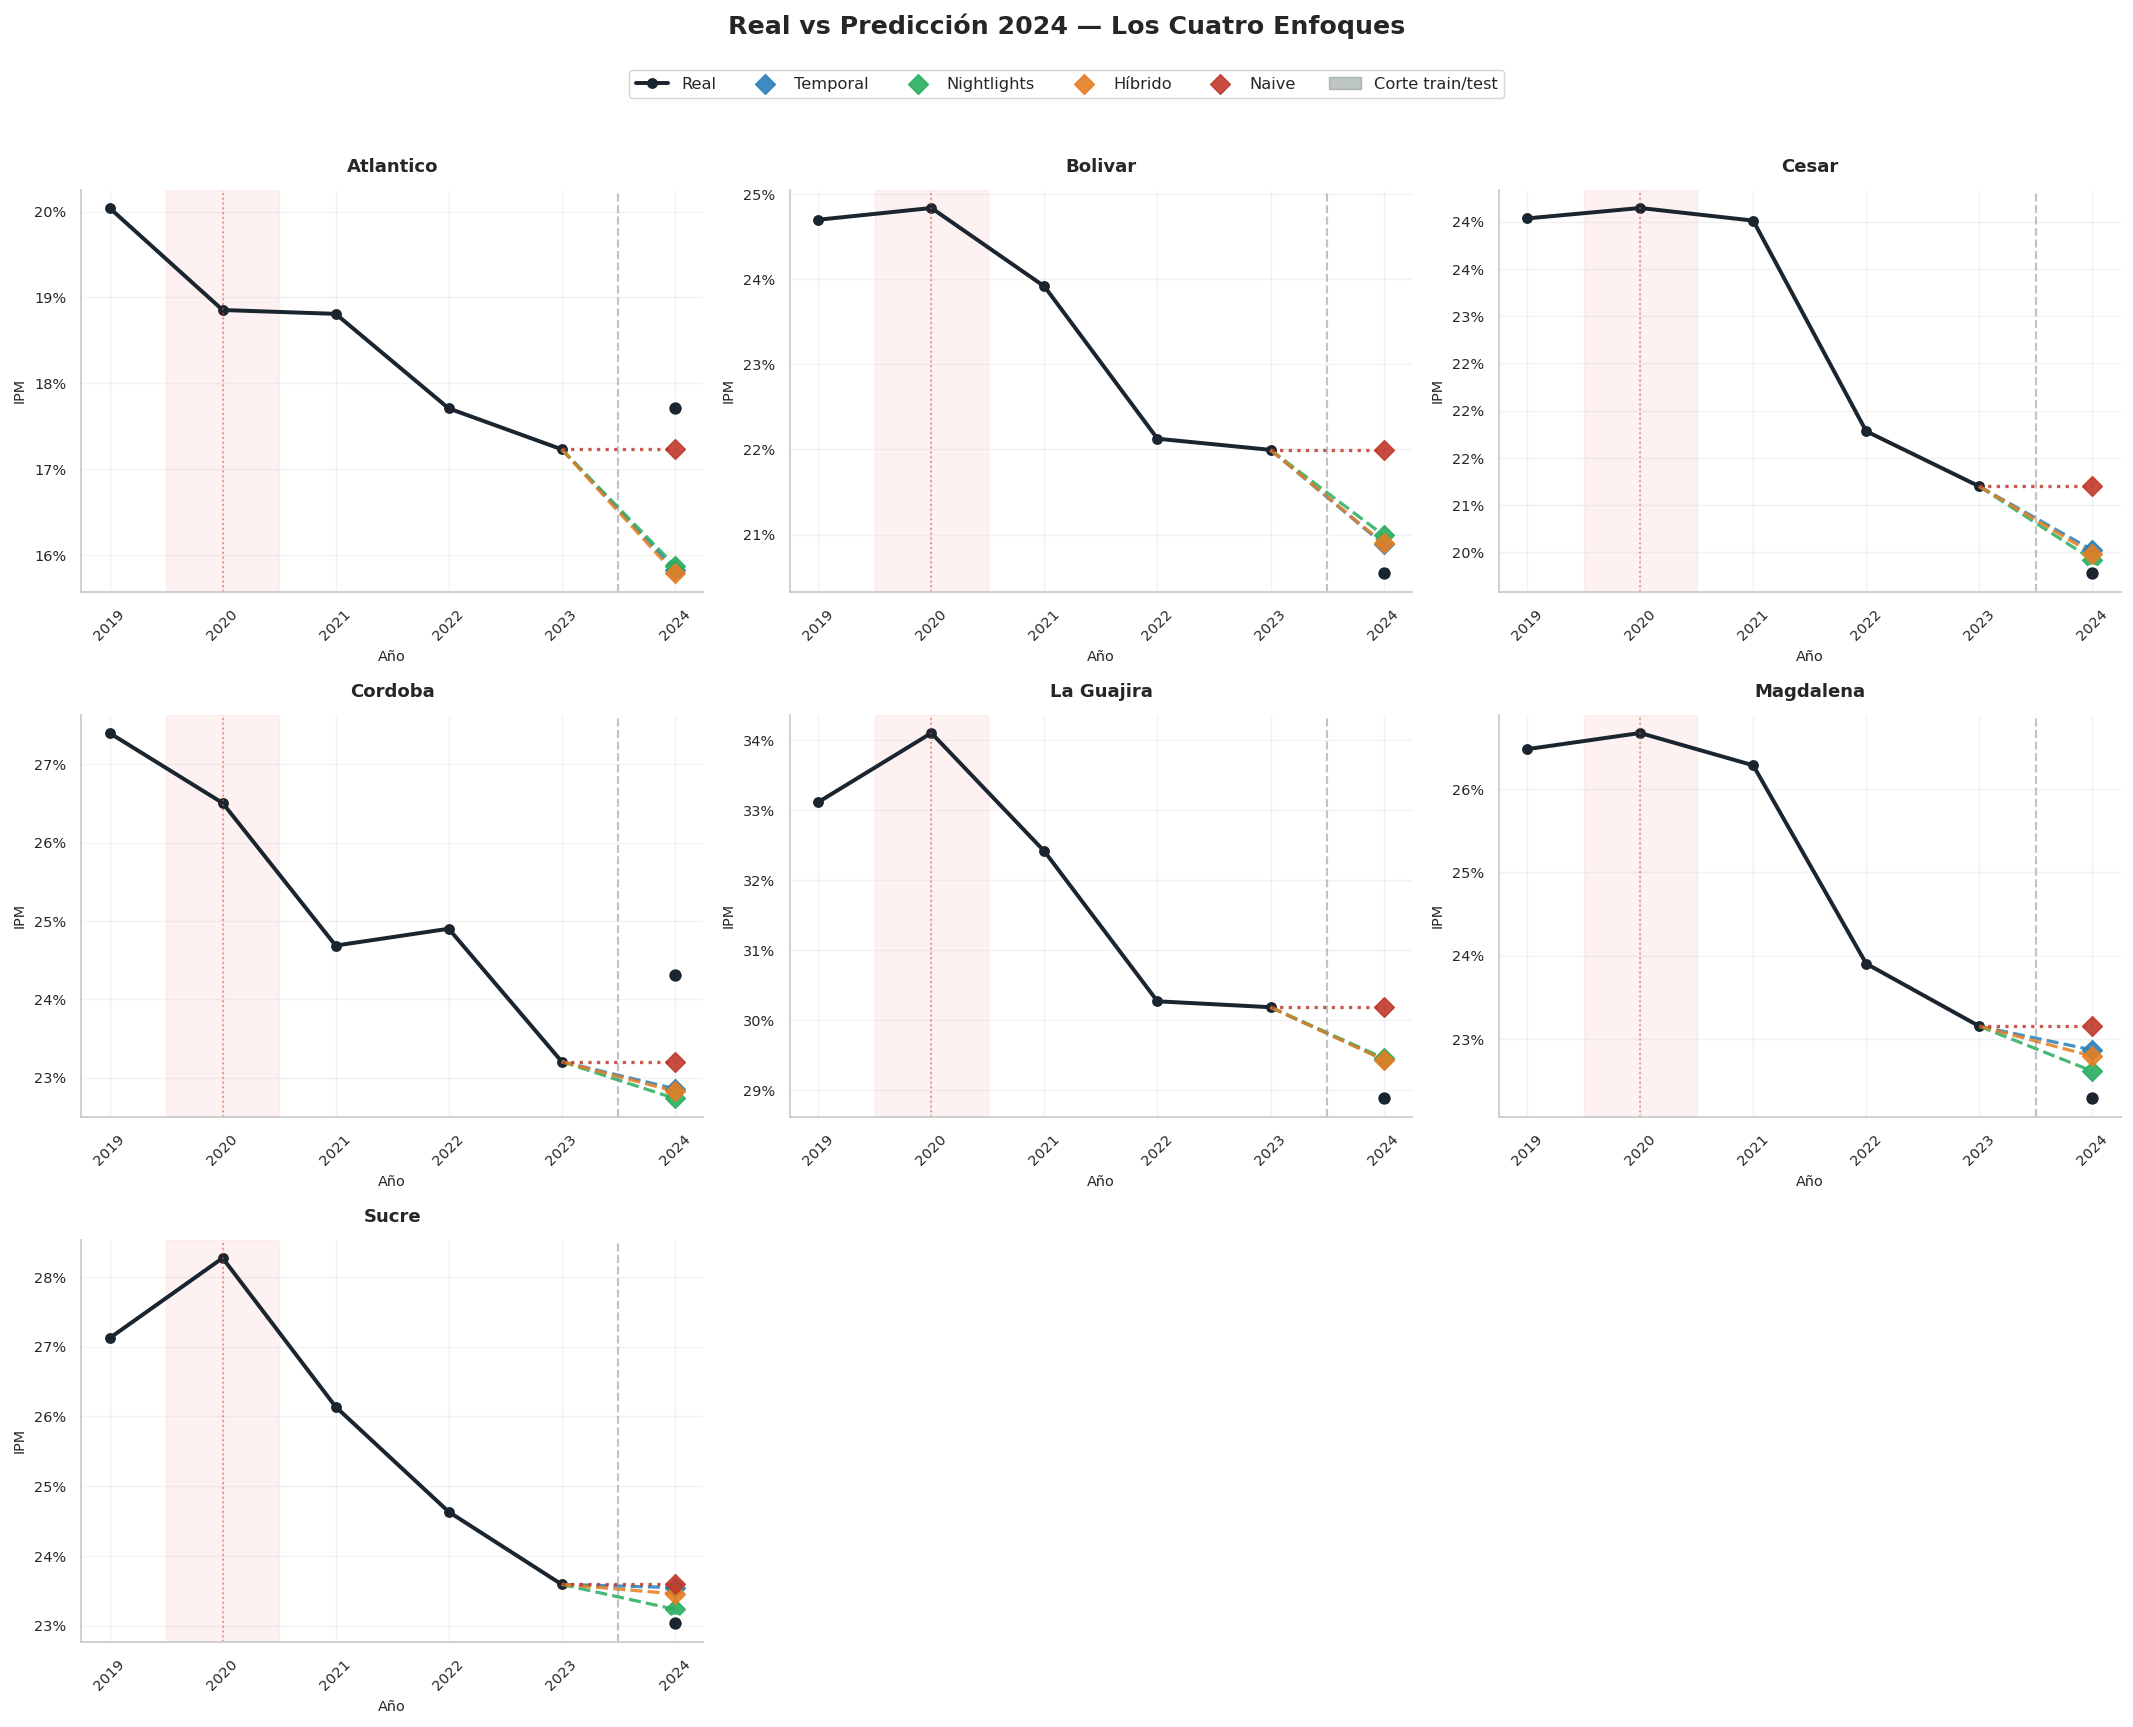

In [32]:
# Serie histórica 2019–2023 como contexto para la comparación
df_hist_2023 = df_model_exog[df_model_exog['año'] <= TRAIN_END].copy()

plot_real_vs_pred_2024(
    df_hist=df_hist_2023,
    df_test=test_hybrid,
    temporal_pred=temporal_pred_plot.values,
    light_pred=light_pred_plot.values,
    hybrid_pred=hybrid_pred_plot.values,
    naive_pred=naive_pred_plot.values,
    n_cols=3
)


> **Patrones por departamento:**
> - **Bolívar, Cesar y Magdalena:** el modelo Nightlights captura reducciones más aceleradas del IPM que no eran visibles en la sola tendencia histórica, sugiriendo que la señal satelital detecta transformaciones económicas recientes antes de que se reflejen en los indicadores formales.
> - **Atlántico y La Guajira:** el enfoque Temporal es el más preciso. Las señales satelitales tienden a sobreestimar la reducción de pobreza en estos territorios, probablemente porque la actividad luminosa capturada por VIIRS incluye zonas industriales o portuarias no necesariamente correlacionadas con mejoras en el bienestar de los hogares.
> - **Córdoba:** todos los modelos fallan en reproducir el repunte de 2024, que representa un quiebre estructural respecto a la tendencia decreciente previa. El modelo Híbrido es el más equilibrado: no produce el error más bajo, pero evita los errores extremos de los enfoques univariados.

### 9.4 Dispersión: Real vs Predicho


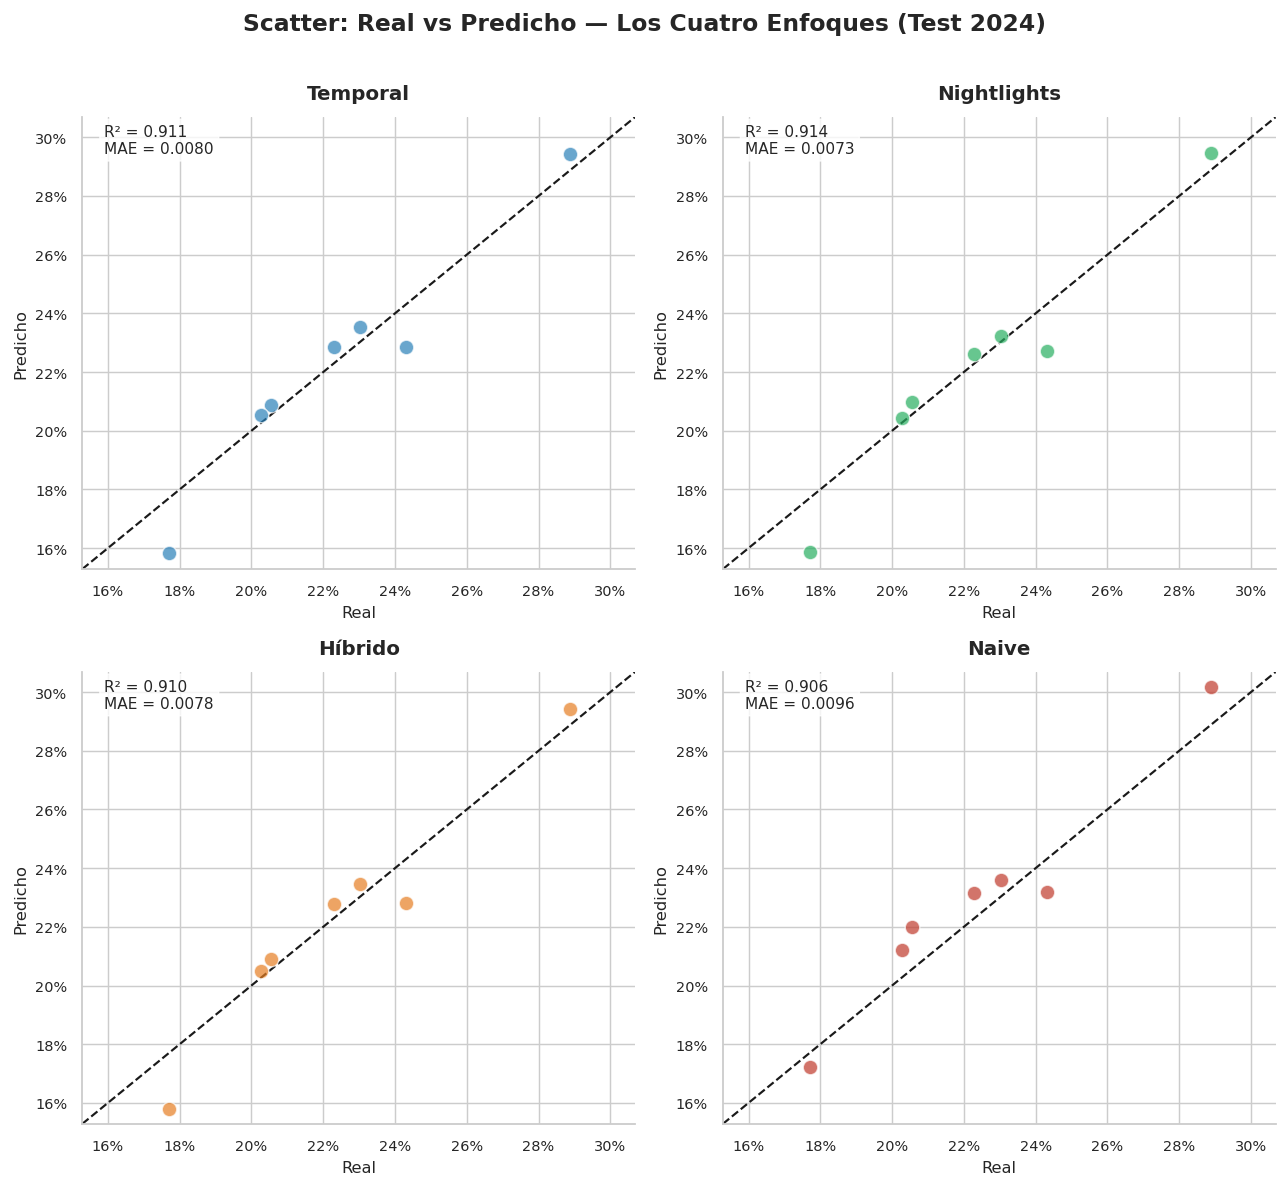

In [33]:
# Scatter 2x2: real vs predicho por enfoque
# Los puntos bien predichos se alinean cerca de la diagonal y = x.
# La distancia a la diagonal indica el error para cada departamento.
# Las métricas R² y MAE se anotan directamente sobre cada panel.
plot_scatter_all(
    y_test_plot.values,
    temporal_pred_plot.values,
    light_pred_plot.values,
    hybrid_pred_plot.values,
    naive_pred_plot.values
)


> **Hallazgo:** el gráfico de dispersión confirma los resultados numéricos. **Nightlights** alcanza el R² más alto y el MAE más bajo en el test de 2024, con los puntos más apretados alrededor de la diagonal. El enfoque **Temporal** es muy cercano en R², pero subestima marginalmente los departamentos en el rango medio del IPM (0.20–0.26). Los enfoques **Híbrido** y **Naive** comparten el mismo MAE absoluto, aunque sus errores se distribuyen en departamentos distintos.

### 9.5 Diagnóstico de Error por Departamento

El mapa de calor revela si algún departamento genera errores sistemáticamente altos en todos los enfoques (indicando heterogeneidad no modelada) o si los errores son idiosincráticos de ciertos enfoques en ciertos territorios.


MAE desagregado por departamento (test 2024):
                     Temporal  Nightlights  Híbrido   Naive
departamento_nombre                                        
Cesar                 0.00247      0.00147  0.00211 0.00922
Bolivar               0.00341      0.00449  0.00354 0.01451
Sucre                 0.00515      0.00203  0.00425 0.00560
Magdalena             0.00581      0.00327  0.00508 0.00867
La Guajira            0.00560      0.00575  0.00552 0.01304
Cordoba               0.01448      0.01571  0.01481 0.01101
Atlantico             0.01881      0.01836  0.01926 0.00481


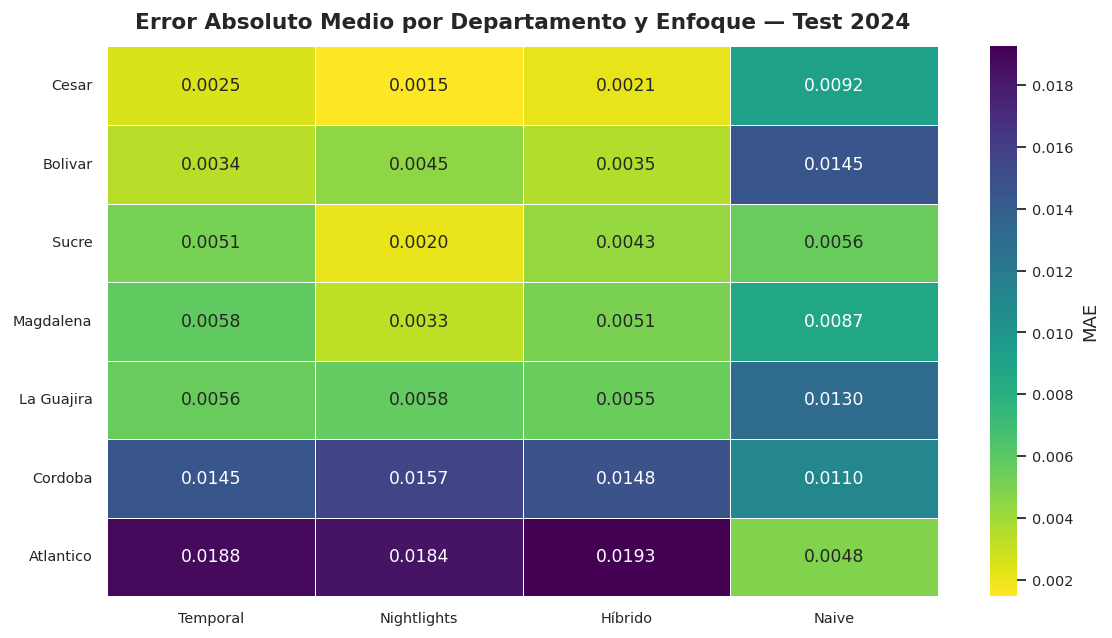

In [34]:
# Error absoluto por departamento — mapa de calor
df_err = test_hybrid[['departamento_nombre']].copy().reset_index(drop=True)
df_err['Temporal']    = np.abs(y_test_plot.values - temporal_pred_plot.values)
df_err['Nightlights'] = np.abs(y_test_plot.values - light_pred_plot.values)
df_err['Híbrido']     = np.abs(y_test_plot.values - hybrid_pred_plot.values)
df_err['Naive']       = np.abs(y_test_plot.values - naive_pred_plot.values)

err_by_depto = (
    df_err.groupby('departamento_nombre')[['Temporal', 'Nightlights', 'Híbrido', 'Naive']]
    .mean()
    .rename(index=title_case_depto)
    .sort_values('Híbrido')
)

print('MAE desagregado por departamento (test 2024):')
print(err_by_depto.to_string(float_format='{:.5f}'.format))
plot_error_heatmap(err_by_depto)


> **Hallazgo — Heterogeneidad territorial del error:**
> - **Nightlights** domina en Cesar, Sucre y Magdalena (errores más bajos en esos departamentos), donde las transformaciones económicas recientes son visibles en la señal satelital.
> - **Temporal** es el más preciso en Atlántico, donde los cambios de 2024 son atípicos respecto a la señal satelital pero coherentes con la inercia histórica.
> - **Córdoba** concentra los errores más altos en todos los enfoques — evidencia de un quiebre estructural de 2024 que ningún modelo logra capturar completamente con los datos disponibles.
>
> **Implicación de política:** la heterogeneidad del error territorial sugiere que el monitoreo del IPM se beneficia de un **portafolio de modelos complementarios** — Nightlights para departamentos con dinamismo económico reciente, Temporal como ancla conservadora en territorios con volatilidad atípica.


---
## 10. Forecast 2025 con Intervalos de Predicción

La proyección para 2025 requiere dos pasos adicionales respecto a la evaluación en test:

1. **Reentrenar** cada modelo con todos los datos disponibles (2019–2024), incorporando la información más reciente antes de predecir el horizonte futuro.
2. **Construir los features de 2025** a partir de la última observación disponible de cada departamento (2024): `ipm_lag1 = ipm_2024_real`, `trend = trend_2024 + 1`, `pandemia = 0`, `viirs = última observación VIIRS disponible`.

Los intervalos de predicción se construyen mediante **bootstrap sobre residuos históricos** (500 iteraciones). Este enfoque captura la incertidumbre de predicción — no solo la incertidumbre sobre los parámetros — bajo el supuesto de que la distribución de los errores futuros es similar a la de los errores históricos.


In [35]:
# Construcción de features para el año 2025
# Se toma el último registro disponible de cada departamento (2024)
# y se proyectan los features hacia el horizonte siguiente.
df_full  = df_model_exog.copy()
df_last  = (
    df_full.sort_values(['departamento_nombre', 'año'])
    .groupby('departamento_nombre').last().reset_index()
)

df_future = df_last[['departamento_nombre']].copy()
df_future['año']                = FCST_YEAR
df_future['ipm_lag1']           = df_last['ipm']              # IPM real de 2024 como rezago
df_future['trend']              = df_last['trend'] + 1        # siguiente paso en la tendencia
df_future['pandemia']           = 0                           # fuera del periodo de pandemia
df_future['viirs_weighted_log'] = df_last['viirs_weighted_log']  # última obs. disponible

deptos_2025       = df_future['departamento_nombre'].tolist()
X_future_temporal = df_future[FEATURES_NUM_TEMPORAL + FEATURES_CAT]
X_future_light    = df_future[FEATURES_NUM_LIGHT    + FEATURES_CAT]
X_future_hybrid   = df_future[FEATURES_NUM_HYBRID   + FEATURES_CAT]

print('Features 2025 construidas:')
print(df_future[['departamento_nombre', 'ipm_lag1', 'trend', 'viirs_weighted_log']].to_string(index=False))


Features 2025 construidas:
departamento_nombre  ipm_lag1  trend  viirs_weighted_log
          ATLANTICO  0.177127      7            2.282569
            BOLIVAR  0.205445      7            0.862481
              CESAR  0.202766      7            0.579938
            CORDOBA  0.243045      7            0.604144
         LA GUAJIRA  0.288822      7            0.585322
          MAGDALENA  0.222874      7            0.712606
              SUCRE  0.230296      7            0.899089


In [36]:
# Reentrenamiento con todos los datos disponibles (2019–2024)
# El reentrenamiento completo maximiza la información histórica antes de proyectar.
df_fe_full     = df_fe.copy()
X_full_temp_fe = df_fe_full[FEATURES_NUM_TEMPORAL + FEATURES_CAT]
y_full_temp_fe = df_fe_full[TARGET]
w_full_temp_fe = df_fe_full[WEIGHT_COL]

X_full_light = df_full[FEATURES_NUM_LIGHT  + FEATURES_CAT]; y_full_light = df_full[TARGET]; w_full_light = df_full[WEIGHT_COL]
X_full_hybrid= df_full[FEATURES_NUM_HYBRID + FEATURES_CAT]; y_full_hybrid= df_full[TARGET]; w_full_hybrid= df_full[WEIGHT_COL]

pipe_full_temporal = train_model(MODELS[best_name_temporal], prep_temporal,
                                  X_full_temp_fe, y_full_temp_fe, w_full_temp_fe)
pipe_full_light    = train_model(MODELS[best_name_light],    prep_light,
                                  X_full_light,   y_full_light,   w_full_light)
pipe_full_hybrid   = train_model(MODELS[best_name_hybrid],   prep_hybrid,
                                  X_full_hybrid,  y_full_hybrid,  w_full_hybrid)

print('Reentrenamiento completado:')
print(f'  Temporal    : {best_name_temporal} — {len(X_full_temp_fe)} obs')
print(f'  Nightlights : {best_name_light}    — {len(X_full_light)} obs')
print(f'  Híbrido     : {best_name_hybrid}   — {len(X_full_hybrid)} obs')


Reentrenamiento completado:
  Temporal    : Ridge — 42 obs
  Nightlights : Ridge    — 42 obs
  Híbrido     : Ridge   — 42 obs


In [37]:
# Predicción puntual 2025 + Naive
fcst_temporal_point = pipe_full_temporal.predict(X_future_temporal)
fcst_light_point    = pipe_full_light.predict(X_future_light)
fcst_hybrid_point   = pipe_full_hybrid.predict(X_future_hybrid)
fcst_naive_point    = df_future['ipm_lag1'].values

df_forecast_2025 = pd.DataFrame({
    'Departamento':  [title_case_depto(d) for d in deptos_2025],
    'IPM 2024 Real': df_last['ipm'].values,
    'Temporal':      fcst_temporal_point,
    'Nightlights':   fcst_light_point,
    'Híbrido':       fcst_hybrid_point,
    'Naive':         fcst_naive_point,
})

print('FORECAST IPM 2025 — REGIÓN CARIBE (predicción puntual):')
print('─' * 72)
for c in ['IPM 2024 Real', 'Temporal', 'Nightlights', 'Híbrido', 'Naive']:
    df_forecast_2025[c] = df_forecast_2025[c].map('{:.4f}'.format)
print(df_forecast_2025.to_string(index=False))


FORECAST IPM 2025 — REGIÓN CARIBE (predicción puntual):
────────────────────────────────────────────────────────────────────────
Departamento IPM 2024 Real Temporal Nightlights Híbrido  Naive
   Atlantico        0.1771   0.1561      0.1581  0.1571 0.1771
     Bolivar        0.2054   0.2030      0.2031  0.2032 0.2054
       Cesar        0.2028   0.1985      0.1994  0.1996 0.2028
     Cordoba        0.2430   0.2239      0.2253  0.2244 0.2430
  La Guajira        0.2888   0.2877      0.2881  0.2883 0.2888
   Magdalena        0.2229   0.2208      0.2222  0.2225 0.2229
       Sucre        0.2303   0.2274      0.2291  0.2293 0.2303


In [38]:
# Intervalos de predicción por bootstrap residual (500 iteraciones)
N_BOOTSTRAP = 500

def _fresh_pipe(model_name, preprocessor):
    """Retorna un pipeline no entrenado para el bootstrap."""
    return Pipeline([('preprocess', clone(preprocessor)),
                     ('model',      clone(MODELS[model_name]))])

print('Calculando intervalos de predicción por bootstrap...')

fc_temporal = bootstrap_prediction_intervals(
    _fresh_pipe(best_name_temporal, prep_temporal),
    X_full_temp_fe, y_full_temp_fe, w_full_temp_fe,
    X_future_temporal, n_bootstrap=N_BOOTSTRAP
)
fc_temporal['deptos'] = deptos_2025
print('  ✓ Temporal')

fc_light = bootstrap_prediction_intervals(
    _fresh_pipe(best_name_light, prep_light),
    X_full_light, y_full_light, w_full_light,
    X_future_light, n_bootstrap=N_BOOTSTRAP
)
fc_light['deptos'] = deptos_2025
print('  ✓ Nightlights')

fc_hybrid = bootstrap_prediction_intervals(
    _fresh_pipe(best_name_hybrid, prep_hybrid),
    X_full_hybrid, y_full_hybrid, w_full_hybrid,
    X_future_hybrid, n_bootstrap=N_BOOTSTRAP
)
fc_hybrid['deptos'] = deptos_2025
print('  ✓ Híbrido')

# Naive: intervalos empíricos basados en residuos históricos
naive_residuals = (df_full['ipm'] - df_full['ipm_lag1']).dropna().values
fc_naive = {
    'point':  fcst_naive_point, 'deptos': deptos_2025,
    'ci_80':  {'lower': fcst_naive_point + np.percentile(naive_residuals, 10),
               'upper': fcst_naive_point + np.percentile(naive_residuals, 90)},
    'ci_95':  {'lower': fcst_naive_point + np.percentile(naive_residuals,  2.5),
               'upper': fcst_naive_point + np.percentile(naive_residuals, 97.5)},
}
print('  ✓ Naive (percentiles empíricos)')

forecast_dict = {
    'Temporal': fc_temporal, 'Nightlights': fc_light,
    'Hibrido':  fc_hybrid,   'Naive':       fc_naive,
}
print('\nIntervalos de predicción calculados.')


Calculando intervalos de predicción por bootstrap...
  ✓ Temporal
  ✓ Nightlights
  ✓ Híbrido
  ✓ Naive (percentiles empíricos)

Intervalos de predicción calculados.


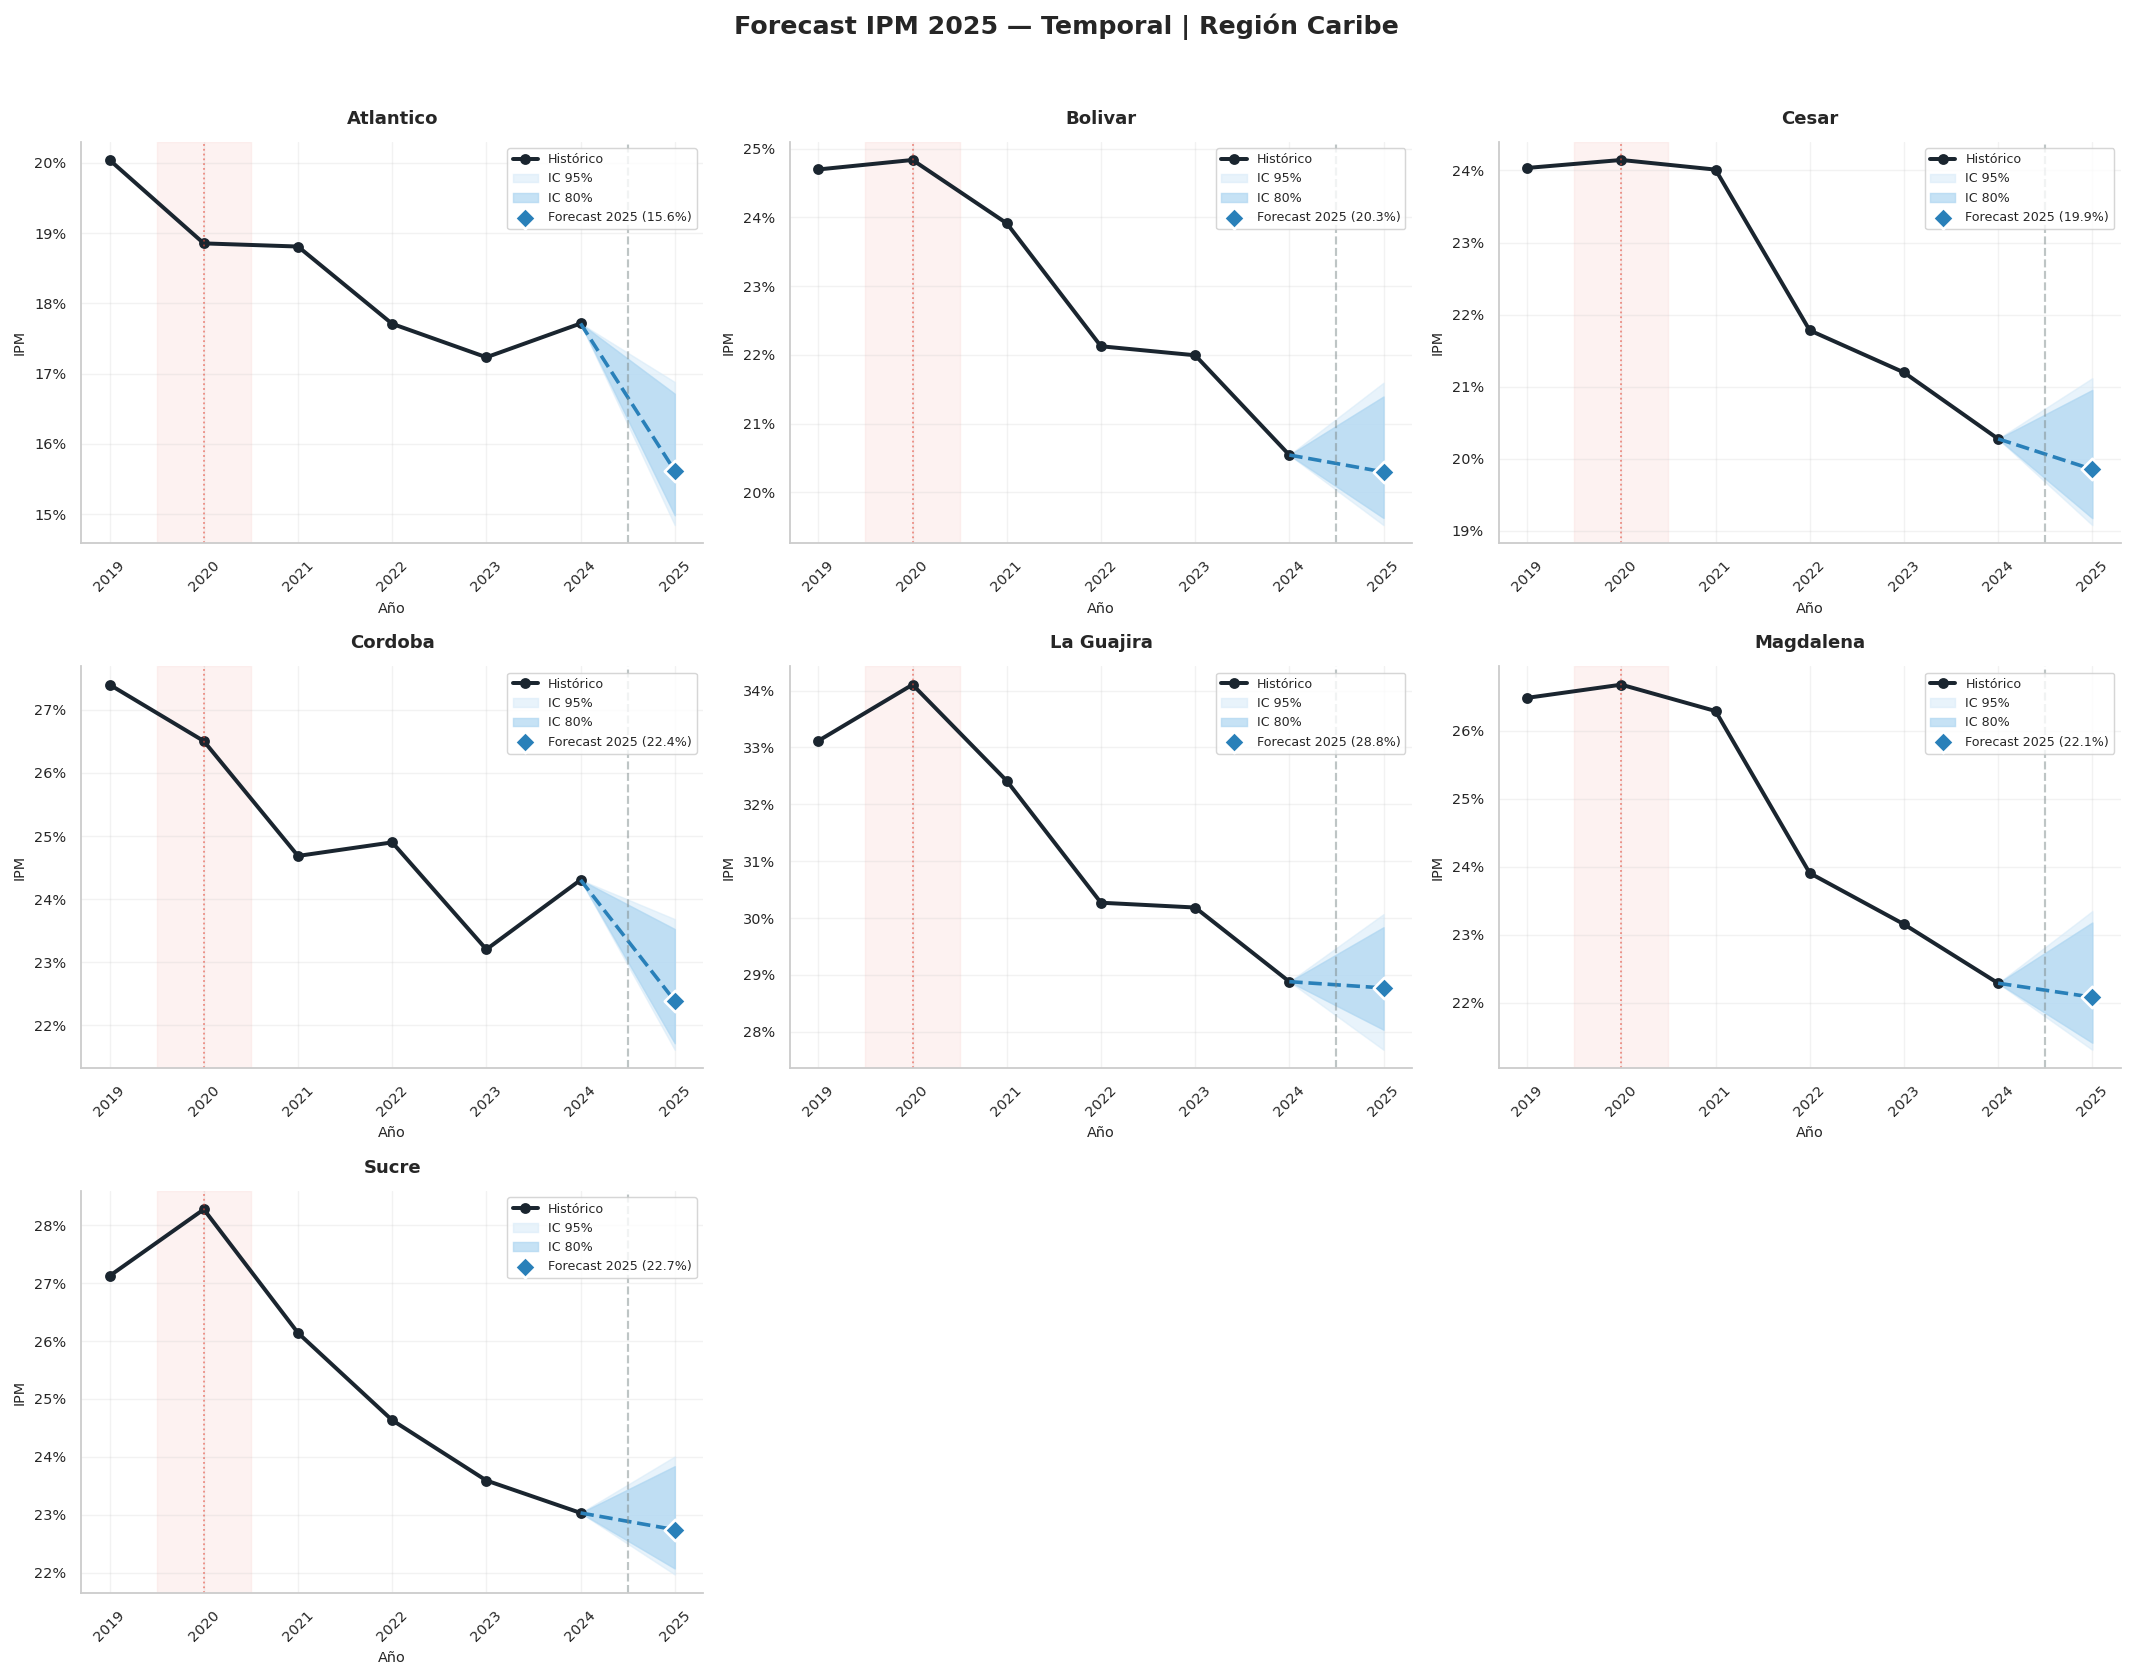

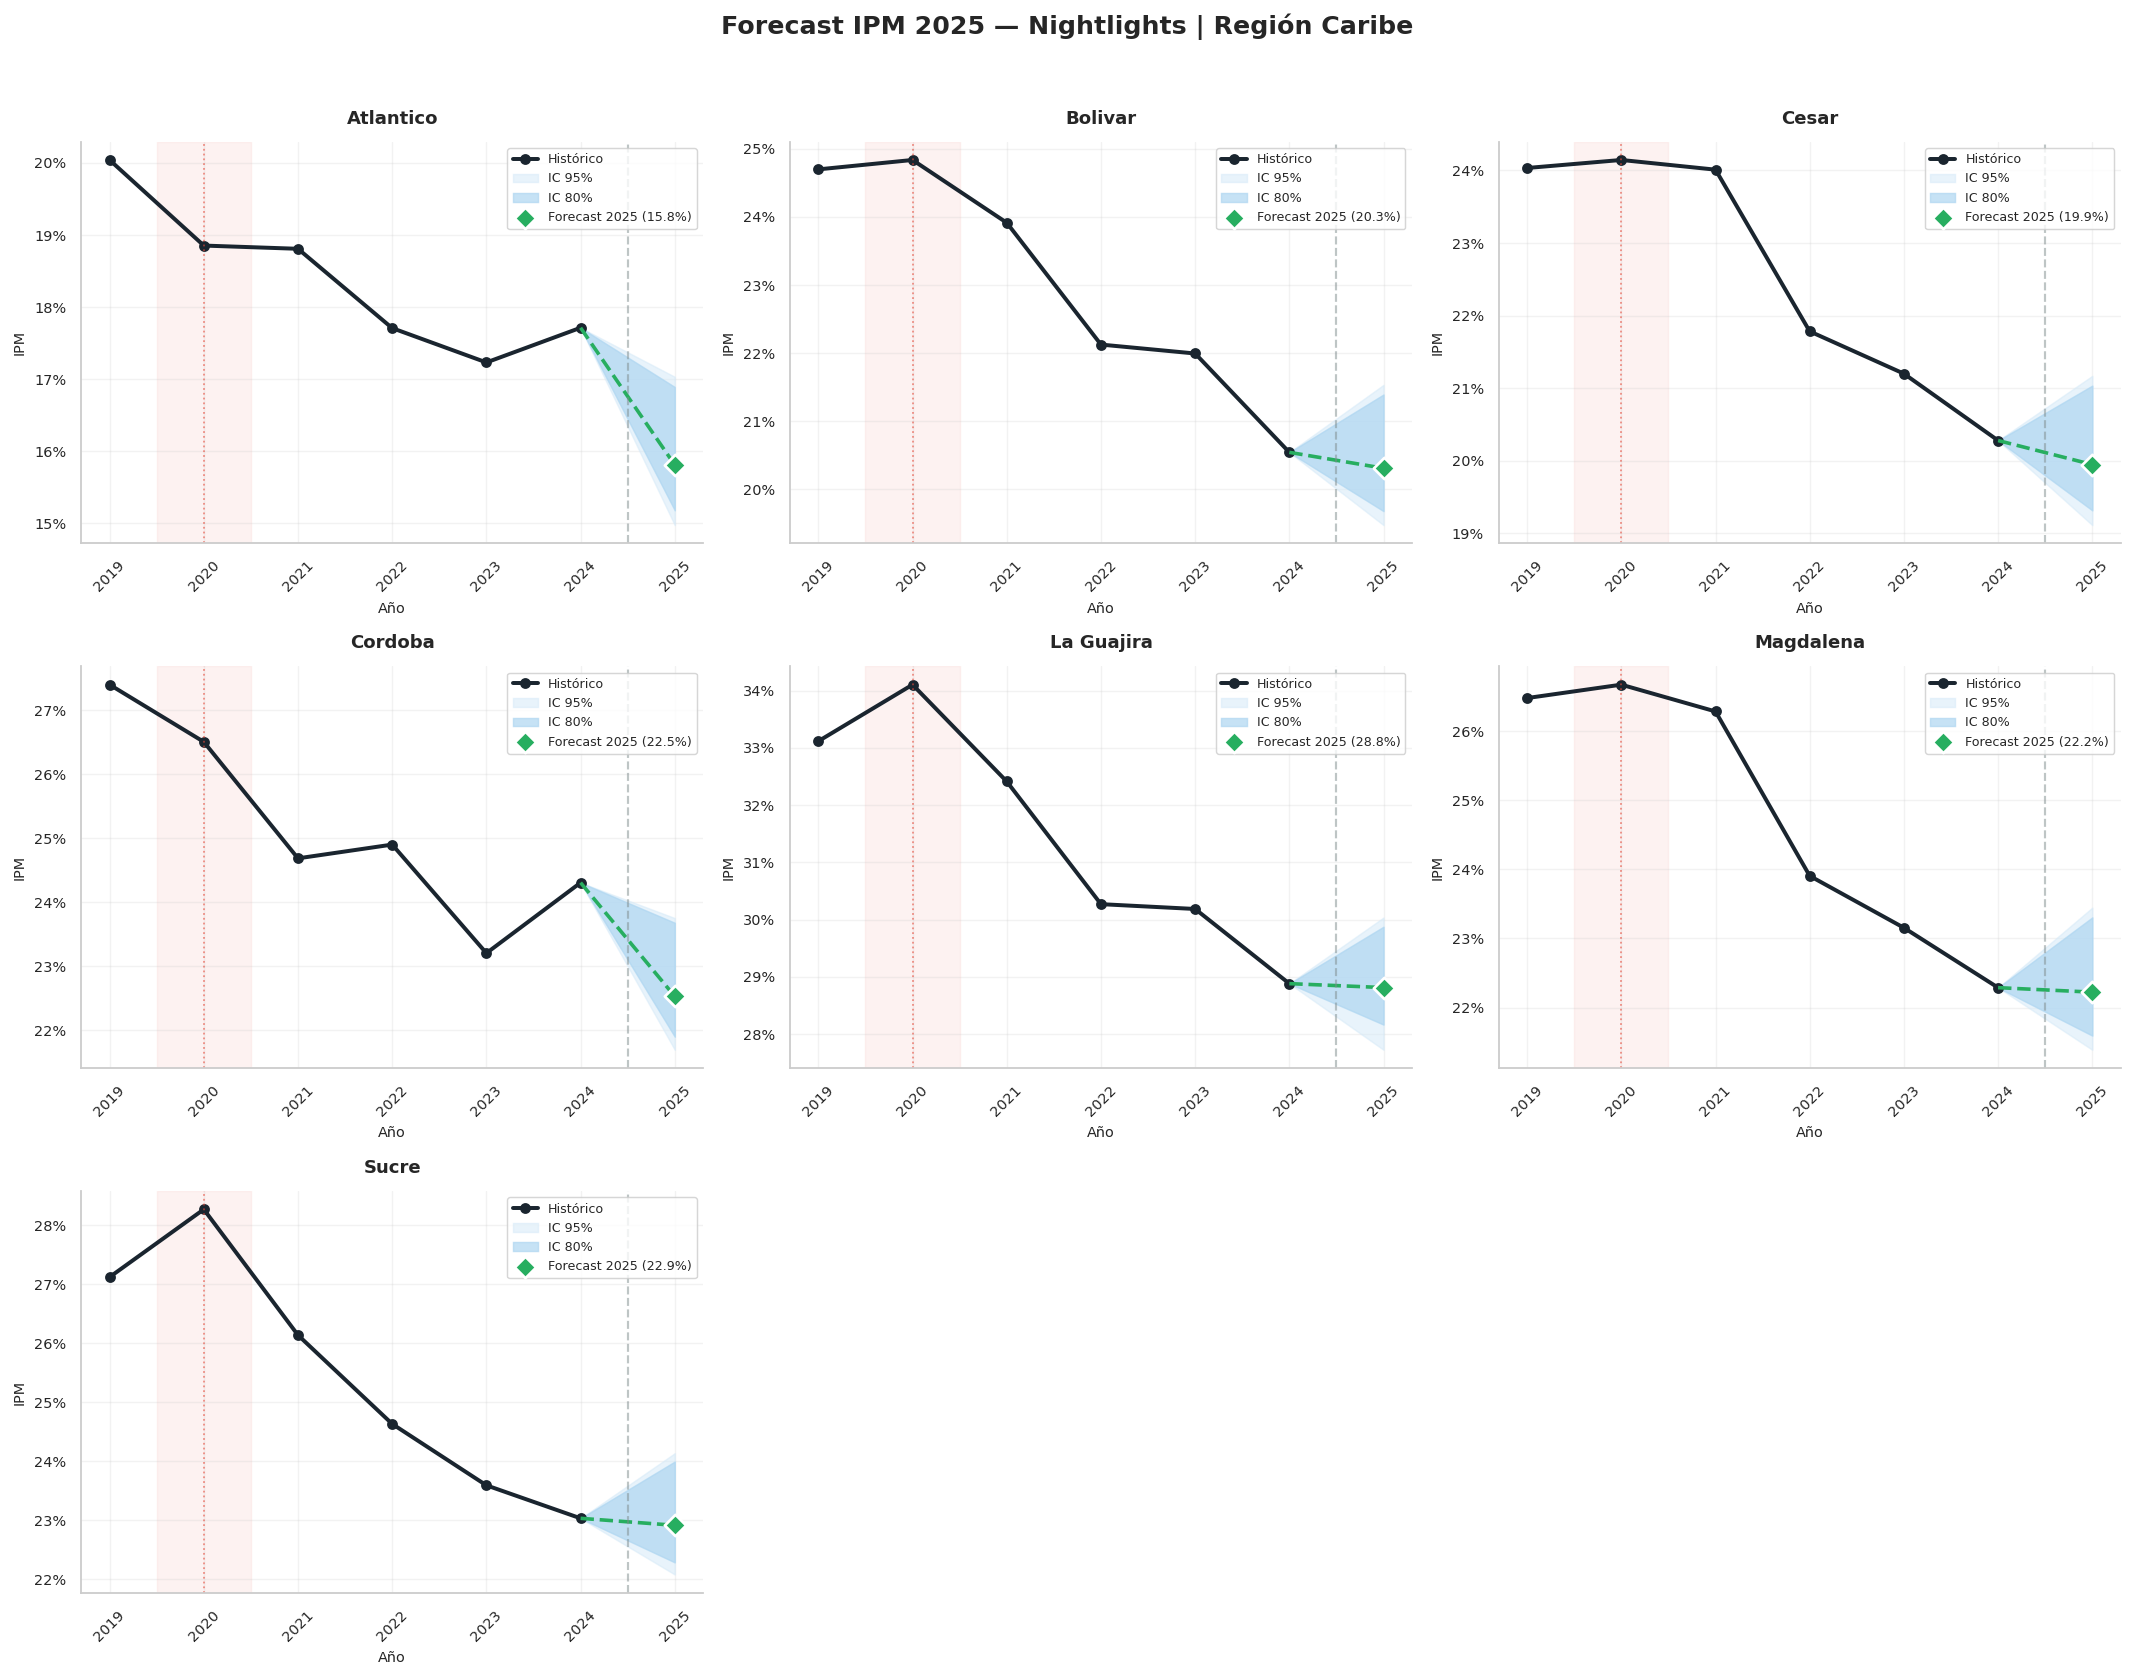

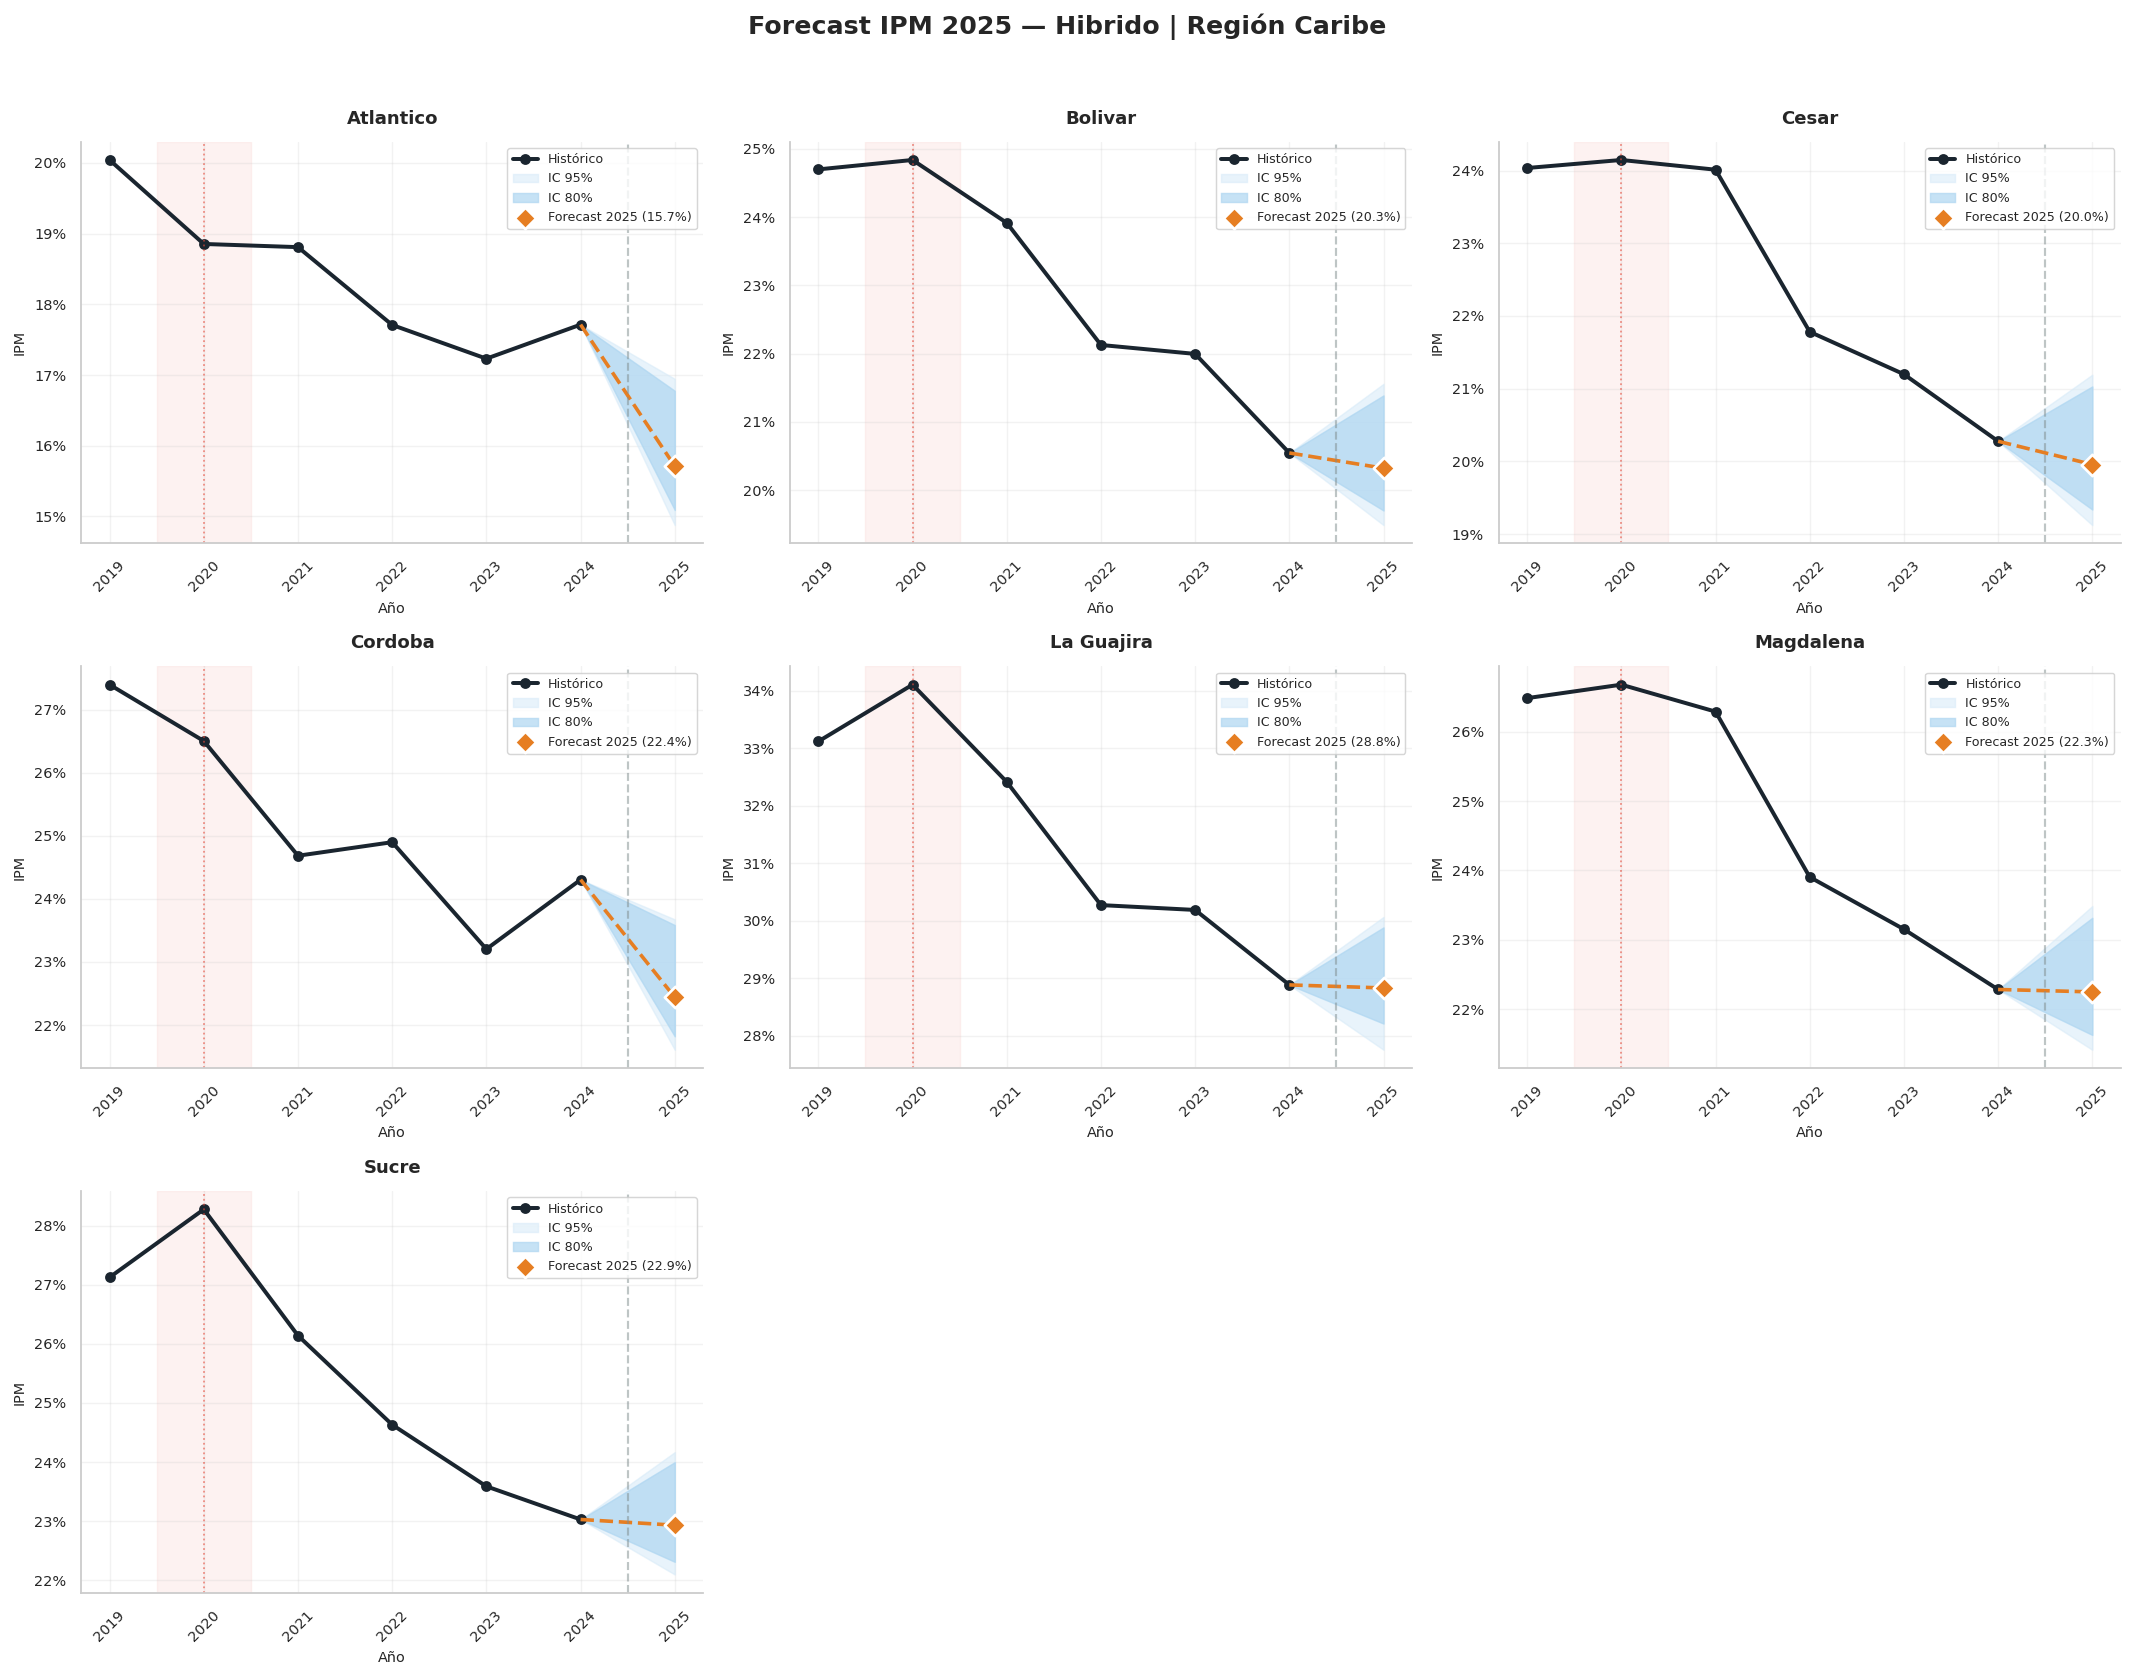

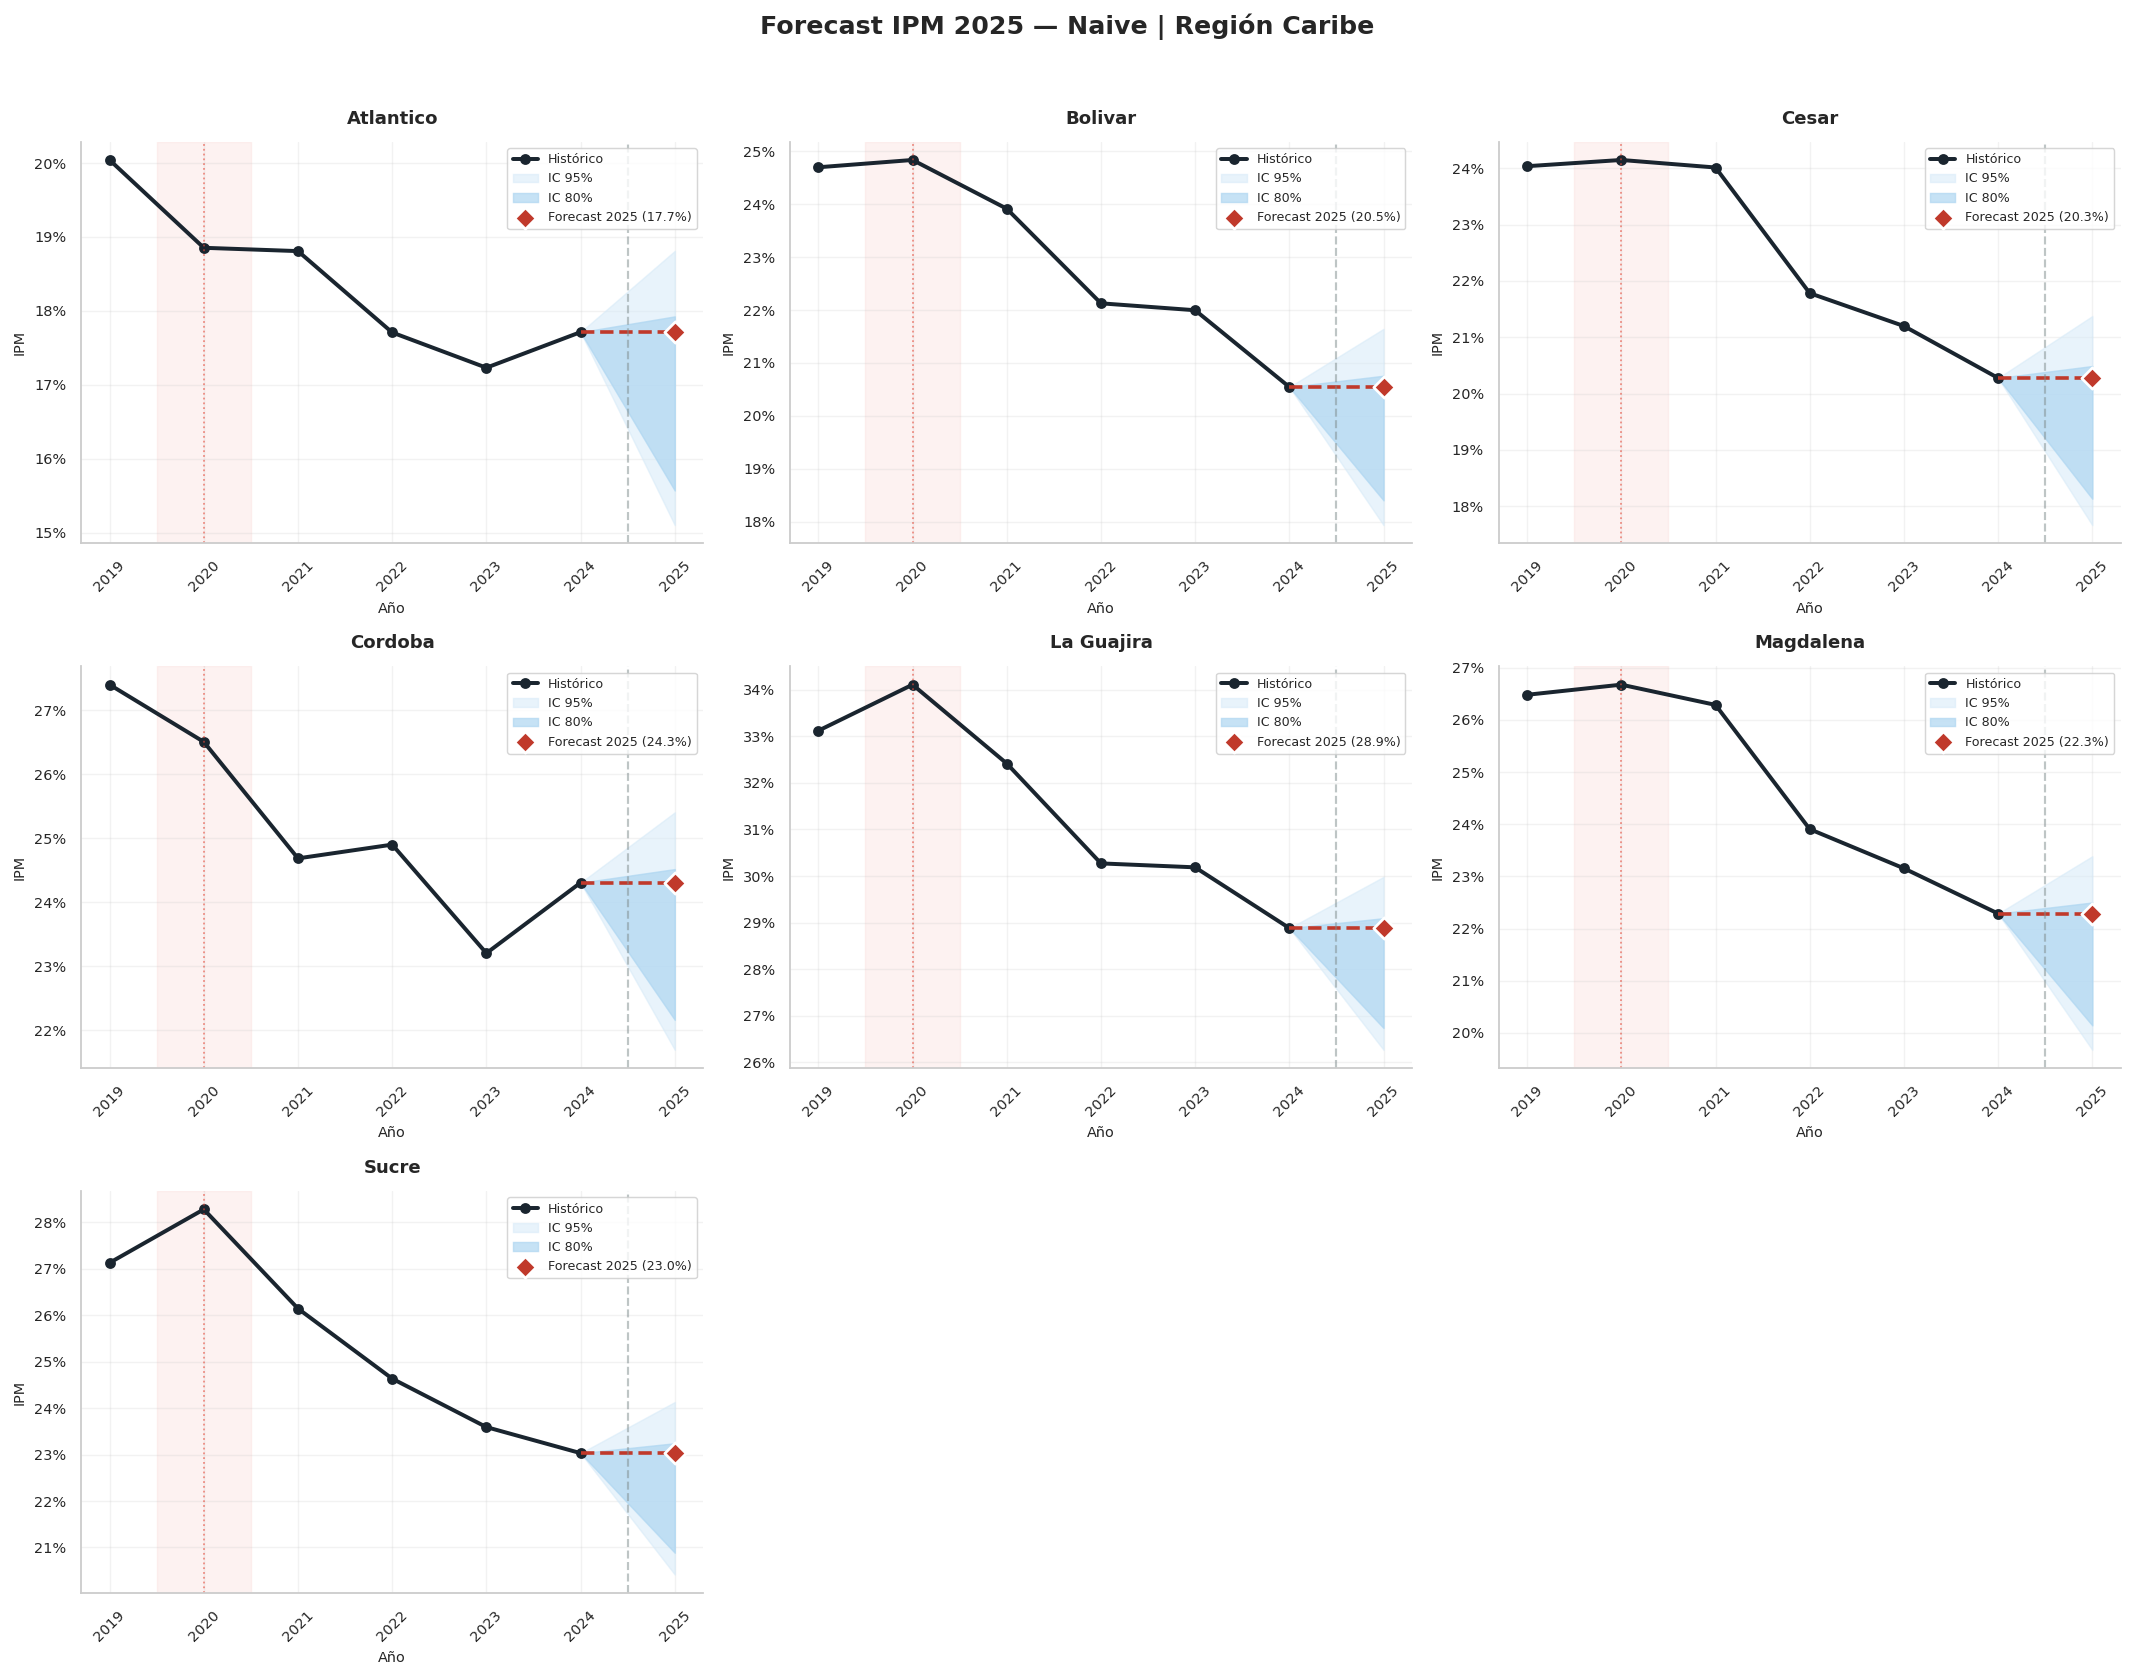

In [39]:
# Gráficos de forecast 2025 con intervalos (uno por enfoque)
# Los intervalos de confianza al 80% y 95% capturan la incertidumbre
# de predicción usando bootstrap sobre los residuos históricos del modelo.
df_hist_completo = df_model_exog.copy()
plot_forecast_2025(df_hist=df_hist_completo, forecast_dict=forecast_dict, n_cols=3)


> **Proyecciones 2025 — patrones principales:**
>
> - **Enfoque Temporal:** anticipa la continuidad de la tendencia decreciente en la mayoría de departamentos, con convergencia gradual. En Atlántico y Córdoba, incorpora los repuntes observados en 2024 sin sobreajustarse a corto plazo, produciendo intervalos de confianza amplios que reflejan mayor incertidumbre.
>
> - **Enfoque Nightlights:** proyecta reducciones más aceleradas del IPM en Atlántico y Córdoba, sugiriendo que la señal satelital detecta dinamismo económico reciente que podría traducirse en mejoras del bienestar aún no reflejadas en los datos del DANE. Los intervalos de confianza son más amplios en Atlántico, territorio con mayor actividad económica urbana.
>
> - **Enfoque Híbrido:** produce las proyecciones más estables. Los intervalos de confianza son los más estrechos entre los tres enfoques para la mayoría de departamentos, lo que sugiere que la integración de información temporal y satelital reduce la varianza del proceso de error. En La Guajira, Sucre y Magdalena, las trayectorias proyectadas convergen hacia tendencias de mediano plazo.


---
## 11. Resumen Ejecutivo


In [40]:
ganador     = comparison_df.index[0]
mae_ganador = float(comparison_df['MAE'].iloc[0])
mae_naive_v = float(naive_metrics['MAE'])

print('MÉTRICAS FINALES — TEST 2024 (ponderadas por factor de expansión):')
print('─' * 70)
for nombre, m in [('Temporal', temporal_metrics), ('Nightlights', light_metrics),
                   ('Híbrido',  hybrid_metrics),   ('Naive',       naive_metrics)]:
    mase_str = f'{m["MASE"]:.4f}' if not np.isnan(m['MASE']) else 'N/A'
    print(f'  {nombre:<14}  MAE={m["MAE"]:.5f}  RMSE={m["RMSE"]:.5f}  '
          f'R²={m["R2"]:.4f}  MASE={mase_str}')

print(f'\n  ✓ Mejor enfoque global: {ganador}  (MAE = {mae_ganador:.5f})')
print()
print('Mejora relativa respecto al Naive:')
for nombre, m in [('Temporal', temporal_metrics), ('Nightlights', light_metrics),
                   ('Híbrido',  hybrid_metrics)]:
    mejora = (mae_naive_v - float(m['MAE'])) / mae_naive_v * 100
    signo  = 'mejora' if mejora > 0 else 'empeora'
    print(f'  {nombre:<14}  vs Naive: {signo} {abs(mejora):.1f}%')


MÉTRICAS FINALES — TEST 2024 (ponderadas por factor de expansión):
──────────────────────────────────────────────────────────────────────
  Temporal        MAE=0.00939  RMSE=0.01141  R²=0.8700  MASE=0.5213
  Nightlights     MAE=0.00900  RMSE=0.01134  R²=0.8716  MASE=0.4998
  Híbrido         MAE=0.00936  RMSE=0.01158  R²=0.8661  MASE=0.5196
  Naive           MAE=0.00941  RMSE=0.01007  R²=0.8987  MASE=0.5229

  ✓ Mejor enfoque global: Nightlights  (MAE = 0.00900)

Mejora relativa respecto al Naive:
  Temporal        vs Naive: mejora 0.3%
  Nightlights     vs Naive: mejora 4.4%
  Híbrido         vs Naive: mejora 0.6%


---
## Conclusiones del Notebook

Este notebook demostró que el IPM de la Región Caribe puede predecirse con alta precisión (R² ≥ 0.87) utilizando información histórica del propio indicador y/o señales de luminosidad nocturna satelital. Los hallazgos principales son:

1. **Las luces nocturnas VIIRS contienen información no redundante sobre la pobreza multidimensional.** El enfoque Nightlights alcanza el mejor MAE en el test fuera de muestra (2024), superando tanto al enfoque puramente temporal como al Naive. Esto valida el uso de datos de percepción remota como proxy del desarrollo socioeconómico en contextos con datos censales de baja frecuencia.

2. **Los modelos lineales regularizados (Ridge) dominan en regímenes de datos pequeños.** En un panel de T ≤ 8 años por departamento, la regularización L2 actúa como mecanismo de estabilización frente a la heterocedasticidad y los choques estructurales. Los métodos de ensamble son competitivos en el Test Set pero menos estables en la Walk-Forward.

3. **No existe un único modelo óptimo para todos los territorios.** Nightlights domina en departamentos con transformaciones económicas recientes; Temporal es más robusto ante quiebres atípicos. El enfoque Híbrido ofrece el mejor balance de incertidumbre en las proyecciones.

4. **El choque de Córdoba en 2024 permanece como un caso abierto.** Ningún modelo reproduce completamente el repunte observado, lo que sugiere la presencia de factores locales no capturados por las variables disponibles y apunta hacia la necesidad de incorporar variables adicionales (criminalidad, inversión pública, ruralidad) en versiones futuras del modelo.

**Próximo notebook:** `04_Procesamiento_Satelital.ipynb` — Pipeline de descarga, interpolación IDW, transformación logarítmica y agregación territorial de las imágenes VIIRS.
